In [ ]:
# !pip install torch torchvision
# !pip install opencv-python
# !pip install torchmetrics
# !pip install segmentation-models-pytorch
# !pip install albumentations
# !pip install matplotlib

In [ ]:
# conda install -c conda-forge pytorch torchvision
# conda install -c conda-forge opencv
# conda install -c conda-forge torchmetrics
# conda install -c conda-forge segmentation-models-pytorch
# conda install -c conda-forge albumentations
# conda install -c conda-forge matplotlib

In [1]:
import os
import json
from PIL import Image
import cv2

import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torchvision
import torchvision.transforms.v2 as tfs
from torchvision import models
from torchvision.models import ResNet101_Weights

from torchmetrics.classification import Accuracy
from torchmetrics.segmentation import DiceScore, MeanIoU

import segmentation_models_pytorch as smp

import albumentations as A
from albumentations.pytorch import ToTensorV2

import numpy as np
import matplotlib.pyplot as plt
from random import randint
from tqdm import tqdm

import gc

In [2]:
!nvidia-smi

Tue Oct 28 16:27:03 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.133.07             Driver Version: 570.133.07     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        On  |   00000000:01:00.0 Off |                  N/A |
| 30%   27C    P8             14W /  575W |       2MiB /  32607MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# gc.collect()
torch.cuda.empty_cache()

In [4]:
def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

get_device()

device(type='cuda')

In [5]:
def make_dirs(paths):
    for path in paths.values():
        os.makedirs(path, exist_ok=True)

In [6]:
def delete_files_in_dir(dir_path):
    if not os.path.isdir(dir_path):
        print(f"Error: '{dir_path}' does not exist.")
        return

    for item_name in os.listdir(dir_path):
        item_path = os.path.join(dir_path, item_name)

        if os.path.isfile(item_path):
            os.remove(item_path)

In [7]:
def show_sample(image, mask):
    img_np = image.cpu().numpy()

    mask_np = mask.cpu().numpy()

    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    axs[0].imshow(img_np, cmap="gray")
    axs[0].set_title("Image")
    axs[0].axis("off")

    axs[1].imshow(mask_np, cmap="gray")
    axs[1].set_title("Mask")
    axs[1].axis("off")

    plt.show()

In [8]:
def load_image_and_mask(image_path, mask_path, transform, is_rgb=False):
    img = None
    if is_rgb:
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    else:
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    img, mask = transform(image=img, mask=mask, is_train=False)
    return img, mask

In [9]:
def load_part_dataset(dataset, size):
    indices = torch.randperm(len(dataset)).tolist()[:size]
    return data.Subset(dataset, indices)

In [10]:
class SegmentationTransform:
    def __init__(self, image_size=512):
        self.train_transform = A.Compose([
            A.Resize(height=image_size, width=image_size, p=1.0,
                     interpolation=cv2.INTER_LINEAR, mask_interpolation=cv2.INTER_NEAREST),

            A.HorizontalFlip(p=0.5),
            A.Affine(
                rotate=(-10, 10),
                scale=(0.9, 1.1),
                translate_percent={'x': (-0.05, 0.05), 'y': (-0.05, 0.05)},
                p=0.5,
            ),

            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),

            A.Normalize(mean=(0.5,), std=(0.5,)),
            ToTensorV2(),
        ])

        self.val_transform = A.Compose([
            A.Resize(height=image_size, width=image_size, p=1.0,
                     interpolation=cv2.INTER_LINEAR,
                     mask_interpolation=cv2.INTER_NEAREST),
            A.Normalize(mean=(0.5,), std=(0.5,)),
            ToTensorV2(),
        ])

    def __call__(self, image, mask, is_train=True):
        if is_train:
            transformed = self.train_transform(image=image, mask=mask)
        else:
            transformed = self.val_transform(image=image, mask=mask)

        return transformed['image'], transformed['mask']

In [11]:
class DentalDataset(data.Dataset):
    def __init__(self, path, transform=None, is_rgb=False, is_train=True):
        self.path = path
        self.transform = transform
        self.is_train = is_train
        self.image_files = []
        self.mask_files = []
        self.is_rgb = is_rgb

        image_path = os.path.join(self.path, "images")
        mask_path = os.path.join(self.path, "masks")

        image_file_names = os.listdir(image_path)
        mask_file_names = os.listdir(mask_path)
        mask_fn_dict = {}
        for fn in mask_file_names:
            curr_file_name = os.path.splitext(fn)
            mask_fn_dict[curr_file_name[0]] = curr_file_name[1]

        for fn in image_file_names:
            curr_file_name = os.path.splitext(fn)
            if curr_file_name[0] in mask_fn_dict:
                self.image_files.append(os.path.join(image_path, fn))
                self.mask_files.append(os.path.join(mask_path, curr_file_name[0] + mask_fn_dict[curr_file_name[0]]))

        self.length = len(self.image_files)

    def __getitem__(self, item):
        image = self.image_files[item]
        mask = self.mask_files[item]

        if self.is_rgb:
            image = cv2.imread(image)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        else:
            image = cv2.imread(image, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask, cv2.IMREAD_GRAYSCALE)

        if self.transform:
            image, mask = self.transform(image, mask, self.is_train)
        return image, mask.float() / 255.0

    def __len__(self):
        return self.length

In [12]:
class SoftDiceLoss(nn.Module):
    def __init__(self, smooth=1):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        num = targets.size(0)
        probs = nn.functional.sigmoid(logits)
        m1 = probs.view(num, -1)
        m2 = targets.view(num, -1)
        intersection = (m1 * m2)

        score = 2 * (intersection.sum(1) + self.smooth) / (m1.sum(1) + m2.sum(1) + self.smooth)
        score = 1 - score.sum() / num
        return score

In [13]:
class ModelTrainer:
    def __init__(self, model, optimizer, bce_loss, dice_loss, device='cuda', deep_supervision=False):
        self.model = model
        self.device = device
        self.optimizer = optimizer
        self.bce_loss = bce_loss
        self.dice_loss = dice_loss
        self.deep_supervision = deep_supervision

    def change_device(self, device):
        if device == 'cuda':
            self.device = device
        else:
            self.device = 'cpu'

    def fit(self, train_data, val_data, epochs, saving_path):
        train_losses = []
        val_losses = []
        best_loss = float("inf")
        patience = 15
        epochs_no_improve = 0

        for epoch in range(epochs):
            train_tqdm = tqdm(train_data, desc=f"Epoch [{epoch+1}/{epochs}]", leave=True)

            train_losses.append(self._train(train_tqdm))
            val_losses.append(self._validate(val_data))

            if val_losses[-1] < best_loss - 0.0001:
                best_loss = val_losses[-1]
                if epoch > 8:
                    self._save_model(epoch+1, train_losses[-1], val_losses[-1], saving_path)
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            print(f"val_loss: {val_losses[-1]:.4f}")
            if epochs_no_improve >= patience:
                break

        return train_losses, val_losses

    def _save_model(self, epoch, train_loss, val_loss, saving_path):
        base_name, ext = os.path.splitext(saving_path)
        new_path = f"{base_name}_epoch_{epoch}{ext}"
        torch.save({
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'loss_function': 'bce+dice',
            'train_loss': train_loss,
            'val_loss': val_loss,
        }, new_path)

    def _train(self, train_tqdm):
        self.model.train()

        loss_sum = 0
        loss_count = len(train_tqdm)
        loss_score = 0
        for i, curr_data in enumerate(train_tqdm):
            x_train = curr_data[0].to(self.device)
            y_train = curr_data[1].to(self.device).unsqueeze(1)

            loss = 0
            if self.deep_supervision:
                predicts = self.model(x_train)
                for predict in predicts:
                    loss += self.bce_loss(predict, y_train) + self.dice_loss(predict, y_train)
                loss /= len(predicts)
            else:
                predict = self.model(x_train)
                loss = self.bce_loss(predict, y_train) + self.dice_loss(predict, y_train)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            loss_sum += loss.item()
            loss_score = loss_sum / loss_count if i+1 == loss_count else loss.item()

            train_tqdm.set_postfix({"train_loss": f"{loss_score:.4f}"})

        return loss_score

    def _validate(self, val_data):
        self.model.eval()

        loss_sum = 0
        loss_count = len(val_data)

        for x_val, y_val in val_data:
            x_val = x_val.to(self.device)
            y_val = y_val.to(self.device).unsqueeze(1)
            with torch.no_grad():
                loss = 0
                if self.deep_supervision:
                    predicts = self.model(x_val)
                    for predict in predicts:
                        loss += self.bce_loss(predict, y_val) + self.dice_loss(predict, y_val)
                    loss /= len(predicts)
                else:
                    predict = self.model(x_val)
                    loss = self.bce_loss(predict, y_val) + self.dice_loss(predict, y_val)
                loss_sum += loss.item()

        return loss_sum / loss_count

In [14]:
class ModelEvaluator:
    def __init__(self, bce_loss, dice_loss, device='cuda'):
        self.bce_loss = bce_loss
        self.dice_loss = dice_loss
        self.device = device
        self.dice = DiceScore(num_classes=2, average="micro", include_background=False, 
                              input_format='index').to(self.device)
        self.iou = MeanIoU(num_classes=2, include_background=False, 
                           input_format='index').to(self.device)
        self.accuracy = Accuracy(task="binary").to(self.device)

    def evaluate_model(self, model, data):
        dice_score = iou_score = acc_score = loss_score = 0
        model.eval()

        for x, y in data:
            x = x.to(self.device)
            y = y.to(self.device).unsqueeze(1)
            with torch.no_grad():
                output = model(x)
                loss = self.bce_loss(output, y) + self.dice_loss(output, y)
                loss_score += loss.item()
                preds = torch.sigmoid(output) > 0.5

                dice_score += self.dice(preds.long(), y.long()).item()
                iou_score += self.iou(preds.long(), y.long()).item()
                acc_score += self.accuracy(preds.long(), y.long()).item()

        return self._get_result(acc_score, dice_score, iou_score, loss_score, len(data))

    def _get_result(self, acc_score, dice_score, iou_score, loss_score, n):
        return {
            "accuracy": acc_score / n,
            "dice": dice_score / n,
            "iou": iou_score / n,
            "loss": loss_score / n
        }

    def evaluate_models(self, models, data):
        dice_score = iou_score = acc_score = 0

        for x, y in data:
            x = x.to(self.device)
            y = y.to(self.device).unsqueeze(1)

            preds = ModelPredictor.predict_batch_for_models(models, x, self.device)
            preds = preds.unsqueeze(1)

            dice_score += self.dice(preds.long(), y.long()).item()
            iou_score += self.iou(preds.long(), y.long()).item()
            acc_score += self.accuracy(preds.long(), y.long()).item()

        return self._get_result_without_loss(acc_score, dice_score, iou_score, len(data))

    def _get_result_without_loss(self, acc_score, dice_score, iou_score, n):
        return {
            "accuracy": acc_score / n,
            "dice": dice_score / n,
            "iou": iou_score / n
        }

In [15]:
class ModelPredictor:
    @staticmethod
    def predict_sample(model, image, device='cuda'):
        image = ModelPredictor._add_dims_for_image(image)

        model.eval()
        with torch.no_grad():
            image = image.to(device)
            image = model(image).squeeze(1)
            image = torch.sigmoid(image) > 0.5

        return image.squeeze(0)

    @staticmethod
    def predict_dataset(model, data, device='cuda'):
        predicted_masks = []

        model.eval()

        for x, y in data:
            x = x.to(device)
            y = y.to(device)
            with torch.no_grad():
                pred = model(x).squeeze(1)
                pred = torch.sigmoid(pred) > 0.5
                predicted_masks.extend(pred)

        return torch.stack(predicted_masks).to(device)

    @staticmethod
    def predict_dataset_for_models(models, data, device='cuda'):
        predicted_masks = []

        for x, y in data:
            x = x.to(device)
            y = y.to(device)
            predicted_masks.extend(ModelPredictor.predict_batch_for_models(models, x, device))

        return torch.stack(predicted_masks).to(device)

    @staticmethod
    def predict_batch_for_models(models, x, device='cuda'):
        preds = []

        with torch.no_grad():
            for model in models:
                model.eval()
                output = model(x.to(device))
                output = torch.sigmoid(output).squeeze(1)
                preds.append(output)

        batch_preds = torch.stack(preds, dim=0)
        return ModelPredictor._get_final_mask(batch_preds, len(models))

    @staticmethod
    def predict_sample_for_models(models, image, device='cuda'):
        image = ModelPredictor._add_dims_for_image(image)

        preds = []
        for i in range(len(models)):
            models[i].eval()
            with torch.no_grad():
                output = models[i](image.to(device)).squeeze(1)
                output = torch.sigmoid(output) > 0.5
                preds.append(output)

        return ModelPredictor._get_final_mask(torch.stack(preds, dim=0), len(models)).squeeze(0)

    @staticmethod
    def _get_final_mask(preds, count_models):
        preds = (preds > 0.5).int()
        votes = preds.sum(dim=0)
        threshold = count_models // 2 + (count_models % 2 > 0)
        return (votes >= threshold).int()


    @staticmethod
    def _add_dims_for_image(image):
        if image.ndim == 3:
            image = image.unsqueeze(0)
        elif image.ndim == 2:
            image = image.unsqueeze(0).unsqueeze(0)
        return image

In [16]:
class Visualizer:
    @staticmethod
    def show_prediction(image, mask, prediction, model_name, is_rgb=False):
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        if is_rgb:
            image = image.permute(1, 2, 0)
            axes[0].imshow(image.numpy())
        else:
            axes[0].imshow(image, cmap='gray')
        axes[0].set_title('Original image')
        axes[0].axis('off')

        axes[1].imshow(mask, cmap='gray')
        axes[1].set_title('Ground truth mask')
        axes[1].axis('off')

        axes[2].imshow(prediction, cmap='gray')
        axes[2].set_title('Predicted mask')
        axes[2].axis('off')

        fig.suptitle(f"Prediction {model_name}")
        plt.tight_layout()
        plt.show()

    @staticmethod
    def show_predictions(image, mask_true, pred_masks, titles=None, ncols=4):
        images = [image, mask_true] + pred_masks
        titles = ["Original image", "Ground truth"] + (titles if titles else [f"Model {i+1}" for i in range(len(pred_masks))])
    
        n_images = len(images)
        nrows = int(np.ceil(n_images / ncols))
    
        plt.figure(figsize=(4 * ncols, 4 * nrows))
        for i, (img, title) in enumerate(zip(images, titles)):
            plt.subplot(nrows, ncols, i + 1)
            if img.ndim == 3 and img.shape[-1] == 3:
                plt.imshow(img)
            else:
                plt.imshow(img, cmap='gray')
            plt.title(title, fontsize=12)
            plt.axis('off')
        plt.tight_layout()
        plt.show()

    @staticmethod
    def show_training_history(train_losses, val_losses):
        epochs = range(1, len(train_losses)+1)
        plt.plot(epochs, train_losses, label="Train loss")
        plt.plot(epochs, val_losses, label="Val loss")
        plt.title('Training and validation loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

In [17]:
class ToothRegionExtractor:
    def __init__(self, target_size = 256, padding = 10):
        self.target_size = target_size
        self.padding = padding
    
    def _get_bbox(self, mask):
        coords = cv2.findNonZero(mask.astype(np.uint8))
        if coords is None:
            return 0, 0, mask.shape[1], mask.shape[0]
        
        x, y, w, h = cv2.boundingRect(coords)
        
        x = max(0, x - self.padding)
        y = max(0, y - self.padding)
        w = min(mask.shape[1] - x, w + 2 * self.padding)
        h = min(mask.shape[0] - y, h + 2 * self.padding)
        
        return x, y, w, h
    
    def _adjust_bbox_to_target(self, x, y, w, h, img_h, img_w):
        if w < self.target_size and h < self.target_size:
            w_new = h_new = self.target_size
        elif w < self.target_size and h >= self.target_size:
            w_new = self.target_size
            h_new = h
        elif h < self.target_size and w >= self.target_size:
            w_new = w
            h_new = self.target_size
        else:
            w_new = w
            h_new = h
        
        x_center = x + w // 2
        y_center = y + h // 2
        
        x_new = max(0, min(img_w - w_new, x_center - w_new // 2))
        y_new = max(0, min(img_h - h_new, y_center - h_new // 2))
        
        return x_new, y_new, w_new, h_new
    
    def _crop_and_resize(self, img, x, y, w, h):
        cropped = img[y:y+h, x:x+w]
        resized = cv2.resize(cropped, (self.target_size, self.target_size), 
                            interpolation=cv2.INTER_LINEAR)
        return resized
    
    def extract_inference(self, image, tooth_mask):
        x, y, w, h = self._get_bbox(tooth_mask)
        x, y, w, h = self._adjust_bbox_to_target(x, y, w, h, 
                                                  image.shape[0], image.shape[1])
        
        cropped_image = self._crop_and_resize(image, x, y, w, h)
        crop_params = {'x': x, 'y': y, 'w': w, 'h': h, 'orig_shape': image.shape[:2]}
        return cropped_image, crop_params
    
    def extract_training(self, image, tooth_mask, caries_mask):
        x, y, w, h = self._get_bbox(tooth_mask)
        x, y, w, h = self._adjust_bbox_to_target(x, y, w, h,
                                                  image.shape[0], image.shape[1])
        
        cropped_image = self._crop_and_resize(image, x, y, w, h)
        
        cropped_caries = caries_mask[y:y+h, x:x+w]
        cropped_caries = cv2.resize(cropped_caries, (self.target_size, self.target_size),
                                   interpolation=cv2.INTER_NEAREST)
        
        return cropped_image, cropped_caries
    
    def restore_full_mask(self, cropped_pred, crop_params):
        x, y, w, h = crop_params['x'], crop_params['y'], crop_params['w'], crop_params['h']
        orig_h, orig_w = crop_params['orig_shape']
        
        resized_pred = cv2.resize(cropped_pred, (w, h), 
                                 interpolation=cv2.INTER_LINEAR)
        
        full_mask = np.zeros((orig_h, orig_w), dtype=cropped_pred.dtype)
        full_mask[y:y+h, x:x+w] = resized_pred
        return full_mask

In [18]:
def save_cropped_dataset(tooth_model, dataset, output_dir, device='cuda'):
    img_dir = os.path.join(output_dir, 'images')
    mask_dir = os.path.join(output_dir, 'masks')
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(mask_dir, exist_ok=True)
    
    tooth_model.eval()
    extractor = ToothRegionExtractor(target_size=256, padding=10)
    
    loader = data.DataLoader(dataset, batch_size=1, shuffle=False)
    
    for idx, (image, caries_mask) in enumerate(tqdm(loader, desc="Processing")):
        with torch.no_grad():
            tooth_pred = tooth_model(image.to(device))
            tooth_mask = torch.sigmoid(tooth_pred).cpu().numpy()[0, 0]
            tooth_mask = (tooth_mask > 0.5).astype(np.uint8)
        
        img_np = image.cpu().numpy()[0, 0]
        caries_np = caries_mask.cpu().numpy()[0]
        
        cropped_img, cropped_caries = extractor.extract_training(
            img_np, tooth_mask, caries_np
        )
        
        filename = f"{idx:05d}.png"
        img_to_save = cropped_img.copy()
        img_to_save = (img_to_save - img_to_save.min()) / (img_to_save.max() - img_to_save.min())
        img_to_save = (img_to_save * 255).astype(np.uint8)
        cv2.imwrite(os.path.join(img_dir, filename), img_to_save)
        cv2.imwrite(os.path.join(mask_dir, filename), (cropped_caries * 255).astype(np.uint8))

### U-Net

In [19]:
class UnetTwoConvLayers(nn.Module):
    def __init__(self, in_channels, out_channels, is_dropout=False, dropout_rate=0.2):
        super().__init__()
        block = [
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(out_channels),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(out_channels)
        ]
        if is_dropout:
            block.append(nn.Dropout2d(p=dropout_rate))
            
        self.model = nn.Sequential(*block)

    def forward(self, x):
        return self.model(x)


class UnetEncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, is_dropout=False, dropout_rate=0.2):
        super().__init__()
        self.block = UnetTwoConvLayers(in_channels, out_channels, is_dropout, dropout_rate)
        self.max_pool = nn.MaxPool2d(2)

    def forward(self, x):
        x = self.block(x)
        y = self.max_pool(x)
        return y, x

class UnetDecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.transpose = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        self.block = UnetTwoConvLayers(in_channels, out_channels)

    def forward(self, x, y):
        x = self.transpose(x)
        u = torch.cat([x, y], dim=1)
        u = self.block(u)
        return u


class UnetModel(nn.Module):
    def __init__(self, in_channels=1, num_classes=1, is_dropout=False, dropout_rate=0.2):
        super().__init__()
        self.enc_block1 = UnetEncoderBlock(in_channels, 64)
        self.enc_block2 = UnetEncoderBlock(64, 128, is_dropout, dropout_rate-0.1)
        self.enc_block3 = UnetEncoderBlock(128, 256, is_dropout, dropout_rate)
        self.enc_block4 = UnetEncoderBlock(256, 512, is_dropout, dropout_rate)

        self.bottleneck = UnetTwoConvLayers(512, 1024, is_dropout, dropout_rate+0.1)

        self.dec_block1 = UnetDecoderBlock(1024, 512)
        self.dec_block2 = UnetDecoderBlock(512, 256)
        self.dec_block3 = UnetDecoderBlock(256, 128)
        self.dec_block4 = UnetDecoderBlock(128, 64)

        self.out = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        x, y1 = self.enc_block1(x)
        x, y2 = self.enc_block2(x)
        x, y3 = self.enc_block3(x)
        x, y4 = self.enc_block4(x)

        x = self.bottleneck(x)

        x = self.dec_block1(x, y4)
        x = self.dec_block2(x, y3)
        x = self.dec_block3(x, y2)
        x = self.dec_block4(x, y1)

        return self.out(x)

### Attention U-Net

In [20]:
class AttentionGate(nn.Module):
    def __init__(self, d_channels, s_channels, out_channels):
        super().__init__()
        self.Wd = nn.Sequential(
            nn.Conv2d(d_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        self.Ws = nn.Sequential(
            nn.Conv2d(s_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        self.attention = nn.Sequential(
            nn.Conv2d(out_channels, 1, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, d, skip_connection):
        d1 = self.Wd(d)
        s1 = self.Ws(skip_connection)
        attention = self.attention(F.relu(d1 + s1))
        return skip_connection * attention


class AttentionUnetDecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, attention_channels):
        super().__init__()
        self.transpose = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        self.block = UnetTwoConvLayers(in_channels, out_channels)
        self.attention_block = AttentionGate(out_channels, out_channels, attention_channels)

    def forward(self, x, skip_connection):
        x = self.transpose(x)
        skip_connection = self.attention_block(x, skip_connection)
        u = torch.cat([x, skip_connection], dim=1)
        u = self.block(u)
        return u


class AttentionUnetModel(nn.Module):
    def __init__(self, in_channels=1, num_classes=1, is_dropout=False, dropout_rate=0.2):
        super().__init__()
        self.enc_block1 = UnetEncoderBlock(in_channels, 64)
        self.enc_block2 = UnetEncoderBlock(64, 128, is_dropout, dropout_rate-0.1)
        self.enc_block3 = UnetEncoderBlock(128, 256, is_dropout, dropout_rate)
        self.enc_block4 = UnetEncoderBlock(256, 512, is_dropout, dropout_rate)

        self.bottleneck = UnetTwoConvLayers(512, 1024, is_dropout, dropout_rate+0.1)

        self.dec_block1 = AttentionUnetDecoderBlock(1024, 512, 256)
        self.dec_block2 = AttentionUnetDecoderBlock(512, 256, 128)
        self.dec_block3 = AttentionUnetDecoderBlock(256, 128, 64)
        self.dec_block4 = AttentionUnetDecoderBlock(128, 64, 32)

        self.out = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        x, y1 = self.enc_block1(x)
        x, y2 = self.enc_block2(x)
        x, y3 = self.enc_block3(x)
        x, y4 = self.enc_block4(x)

        x = self.bottleneck(x)

        x = self.dec_block1(x, y4)
        x = self.dec_block2(x, y3)
        x = self.dec_block3(x, y2)
        x = self.dec_block4(x, y1)

        return self.out(x)

### Residual U-Net

In [21]:
class ResidualUnetTwoConvLayers(nn.Module):
    def __init__(self, in_channels, out_channels, is_dropout=False, dropout_rate=0.2):
        super().__init__()
        block = [
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(out_channels),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels)
        ]
        if is_dropout:
            block.append(nn.Dropout2d(p=dropout_rate))
            
        self.model = nn.Sequential(*block)

        self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1) \
            if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        y = self.model(x)
        x = self.shortcut(x)
        y += x
        return F.relu(y)


class ResidualUnetEncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, is_dropout=False, dropout_rate=0.2):
        super().__init__()
        self.block = ResidualUnetTwoConvLayers(in_channels, out_channels, is_dropout, dropout_rate)
        self.max_pool = nn.MaxPool2d(2)

    def forward(self, x):
        x = self.block(x)
        y = self.max_pool(x)
        return y, x

class ResidualUnetDecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.transpose = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        self.block = ResidualUnetTwoConvLayers(in_channels, out_channels)

    def forward(self, x, y):
        x = self.transpose(x)
        u = torch.cat([x, y], dim=1)
        u = self.block(u)
        return u


class ResidualUnetModel(nn.Module):
    def __init__(self, in_channels=1, num_classes=1, is_dropout=False, dropout_rate=0.2):
        super().__init__()
        self.enc_block1 = ResidualUnetEncoderBlock(in_channels, 64)
        self.enc_block2 = ResidualUnetEncoderBlock(64, 128)
        self.enc_block3 = ResidualUnetEncoderBlock(128, 256, is_dropout, dropout_rate)
        self.enc_block4 = ResidualUnetEncoderBlock(256, 512, is_dropout, dropout_rate)

        self.bottleneck = ResidualUnetTwoConvLayers(512, 1024, is_dropout, dropout_rate)

        self.dec_block1 = ResidualUnetDecoderBlock(1024, 512)
        self.dec_block2 = ResidualUnetDecoderBlock(512, 256)
        self.dec_block3 = ResidualUnetDecoderBlock(256, 128)
        self.dec_block4 = ResidualUnetDecoderBlock(128, 64)

        self.out = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        x, y1 = self.enc_block1(x)
        x, y2 = self.enc_block2(x)
        x, y3 = self.enc_block3(x)
        x, y4 = self.enc_block4(x)

        x = self.bottleneck(x)

        x = self.dec_block1(x, y4)
        x = self.dec_block2(x, y3)
        x = self.dec_block3(x, y2)
        x = self.dec_block4(x, y1)

        return self.out(x)

### Residual Attention U-Net

In [22]:
class ResidualAttentionUnetDecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, attention_channels):
        super().__init__()
        self.transpose = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        self.block = ResidualUnetTwoConvLayers(in_channels, out_channels)
        self.attention_block = AttentionGate(out_channels, out_channels, attention_channels)

    def forward(self, x, skip_connection):
        x = self.transpose(x)
        skip_connection = self.attention_block(x, skip_connection)
        u = torch.cat([x, skip_connection], dim=1)
        u = self.block(u)
        return u


class ResidualAttentionUnetModel(nn.Module):
    def __init__(self, in_channels=1, num_classes=1, is_dropout=False, dropout_rate=0.2):
        super().__init__()
        self.enc_block1 = ResidualUnetEncoderBlock(in_channels, 64)
        self.enc_block2 = ResidualUnetEncoderBlock(64, 128, is_dropout, dropout_rate-0.1)
        self.enc_block3 = ResidualUnetEncoderBlock(128, 256, is_dropout, dropout_rate)
        self.enc_block4 = ResidualUnetEncoderBlock(256, 512, is_dropout, dropout_rate)

        self.bottleneck = ResidualUnetTwoConvLayers(512, 1024, is_dropout, dropout_rate+0.1)

        self.dec_block1 = ResidualAttentionUnetDecoderBlock(1024, 512, 256)
        self.dec_block2 = ResidualAttentionUnetDecoderBlock(512, 256, 128)
        self.dec_block3 = ResidualAttentionUnetDecoderBlock(256, 128, 64)
        self.dec_block4 = ResidualAttentionUnetDecoderBlock(128, 64, 32)

        self.out = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        x, y1 = self.enc_block1(x)
        x, y2 = self.enc_block2(x)
        x, y3 = self.enc_block3(x)
        x, y4 = self.enc_block4(x)

        x = self.bottleneck(x)

        x = self.dec_block1(x, y4)
        x = self.dec_block2(x, y3)
        x = self.dec_block3(x, y2)
        x = self.dec_block4(x, y1)

        return self.out(x)

### R2 U-Net

In [23]:
class UnetRecurrentBlock(nn.Module):
    def __init__(self, out_channels, t=2, is_dropout=False, dropout_rate=0.2):
        super().__init__()
        self.t = t
        self.is_dropout = is_dropout
        self.dropout = nn.Dropout2d(p=dropout_rate)
        
        block = [
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ]

        self.conv = nn.Sequential(*block)

    def forward(self, x):
        for i in range(self.t):
            if i == 0:
                new_x = self.conv(x)
            new_x = self.conv(x + new_x)
        if self.is_dropout:
            new_x = self.dropout(new_x)
        return new_x


class R2UnetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, t=2, is_dropout=False, dropout_rate=0.2):
        super().__init__()
        self.conv_1x1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.rcnn = nn.Sequential(
            UnetRecurrentBlock(out_channels, t, is_dropout, dropout_rate),
            UnetRecurrentBlock(out_channels, t, is_dropout, dropout_rate)
        )

    def forward(self, x):
        x = self.conv_1x1(x)
        return x + self.rcnn(x)


class R2UnetEncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, t=2, is_dropout=False, dropout_rate=0.2):
        super().__init__()
        self.block = R2UnetBlock(in_channels, out_channels, t, is_dropout, dropout_rate)
        self.max_pool = nn.MaxPool2d(2)

    def forward(self, x):
        x = self.block(x)
        y = self.max_pool(x)
        return y, x

class R2UnetDecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.transpose = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        self.block = R2UnetBlock(in_channels, out_channels)

    def forward(self, x, y):
        x = self.transpose(x)
        u = torch.cat([x, y], dim=1)
        u = self.block(u)
        return u


class R2UnetModel(nn.Module):
    def __init__(self, in_channels=1, num_classes=1, t=2, is_dropout=False, dropout_rate=0.2):
        super().__init__()
        self.enc_block1 = R2UnetEncoderBlock(in_channels, 64, t)
        self.enc_block2 = R2UnetEncoderBlock(64, 128, t, is_dropout, dropout_rate-0.1)
        self.enc_block3 = R2UnetEncoderBlock(128, 256, t, is_dropout, dropout_rate)
        self.enc_block4 = R2UnetEncoderBlock(256, 512, t, is_dropout, dropout_rate)

        self.bottleneck = R2UnetBlock(512, 1024, t, is_dropout, dropout_rate+0.1)

        self.dec_block1 = R2UnetDecoderBlock(1024, 512)
        self.dec_block2 = R2UnetDecoderBlock(512, 256)
        self.dec_block3 = R2UnetDecoderBlock(256, 128)
        self.dec_block4 = R2UnetDecoderBlock(128, 64)

        self.out = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        x, y1 = self.enc_block1(x)
        x, y2 = self.enc_block2(x)
        x, y3 = self.enc_block3(x)
        x, y4 = self.enc_block4(x)

        x = self.bottleneck(x)

        x = self.dec_block1(x, y4)
        x = self.dec_block2(x, y3)
        x = self.dec_block3(x, y2)
        x = self.dec_block4(x, y1)

        return self.out(x)

### U-Net++

In [24]:
class UnetPlusPlusModel(nn.Module):
    def __init__(self, in_channels=1, num_classes=1, deep_supervision=False, is_dropout=False, dropout_rate=0.3):
        super().__init__()
        filters = [64,128,256,512,1024]
        self.deep_supervision = deep_supervision
        
        self.conv0_0 = UnetTwoConvLayers(in_channels, filters[0])
        self.conv1_0 = UnetTwoConvLayers(filters[0], filters[1], is_dropout, dropout_rate-0.1)
        self.conv2_0 = UnetTwoConvLayers(filters[1], filters[2], is_dropout, dropout_rate)
        self.conv3_0 = UnetTwoConvLayers(filters[2], filters[3], is_dropout, dropout_rate)
        self.conv4_0 = UnetTwoConvLayers(filters[3], filters[4], is_dropout, dropout_rate+0.1)

        self.pool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        self.conv0_1 = UnetTwoConvLayers(filters[0] + filters[1], filters[0])
        self.conv1_1 = UnetTwoConvLayers(filters[1] + filters[2], filters[1])
        self.conv2_1 = UnetTwoConvLayers(filters[2] + filters[3], filters[2])
        self.conv3_1 = UnetTwoConvLayers(filters[3] + filters[4], filters[3])

        self.conv0_2 = UnetTwoConvLayers(filters[0]*2 + filters[1], filters[0])
        self.conv1_2 = UnetTwoConvLayers(filters[1]*2 + filters[2], filters[1])
        self.conv2_2 = UnetTwoConvLayers(filters[2]*2 + filters[3], filters[2])

        self.conv0_3 = UnetTwoConvLayers(filters[0]*3 + filters[1], filters[0])
        self.conv1_3 = UnetTwoConvLayers(filters[1]*3 + filters[2], filters[1])

        self.conv0_4 = UnetTwoConvLayers(filters[0]*4 + filters[1], filters[0])

        if self.deep_supervision:
            self.out1 = nn.Conv2d(filters[0], num_classes, kernel_size=1)
            self.out2 = nn.Conv2d(filters[0], num_classes, kernel_size=1)
            self.out3 = nn.Conv2d(filters[0], num_classes, kernel_size=1)
            self.out4 = nn.Conv2d(filters[0], num_classes, kernel_size=1)
        else:
            self.out4 = nn.Conv2d(filters[0], num_classes, kernel_size=1)

    def forward(self, x):
        x0_0 = self.conv0_0(x)
        x1_0 = self.conv1_0(self.pool(x0_0))
        x2_0 = self.conv2_0(self.pool(x1_0))
        x3_0 = self.conv3_0(self.pool(x2_0))
        x4_0 = self.conv4_0(self.pool(x3_0))

        x0_1 = self.conv0_1(torch.cat([x0_0, self.up(x1_0)], 1))
        x1_1 = self.conv1_1(torch.cat([x1_0, self.up(x2_0)], 1))
        x2_1 = self.conv2_1(torch.cat([x2_0, self.up(x3_0)], 1))
        x3_1 = self.conv3_1(torch.cat([x3_0, self.up(x4_0)], 1))

        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, self.up(x1_1)], 1))
        x1_2 = self.conv1_2(torch.cat([x1_0, x1_1, self.up(x2_1)], 1))
        x2_2 = self.conv2_2(torch.cat([x2_0, x2_1, self.up(x3_1)], 1))

        x0_3 = self.conv0_3(torch.cat([x0_0, x0_1, x0_2, self.up(x1_2)], 1))
        x1_3 = self.conv1_3(torch.cat([x1_0, x1_1, x1_2, self.up(x2_2)], 1))

        x0_4 = self.conv0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up(x1_3)], 1))

        if self.deep_supervision:
            return [self.out1(x0_1), self.out2(x0_2), self.out3(x0_3), self.out4(x0_4)]

        return self.out4(x0_4)

### U-Net 3+

In [25]:
class Unet3PlusModel(nn.Module):
    def __init__(self, in_channels=1, num_classes=1, is_dropout=False, dropout_rate=0.3):
        super().__init__()
        filters = [64, 128, 256, 512, 1024]

        self.e1_conv = UnetTwoConvLayers(in_channels, filters[0])
        self.e2_conv = UnetTwoConvLayers(filters[0], filters[1], is_dropout, dropout_rate-0.1)
        self.e3_conv = UnetTwoConvLayers(filters[1], filters[2], is_dropout, dropout_rate)
        self.e4_conv = UnetTwoConvLayers(filters[2], filters[3], is_dropout, dropout_rate)
        self.e5_conv = UnetTwoConvLayers(filters[3], filters[4], is_dropout, dropout_rate+0.1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        cat_channels = filters[0]
        cat_blocks = 5
        up_channels = cat_channels * cat_blocks

        self.e1_d4 = self.make_conv(filters[0], cat_channels)
        self.e2_d4 = self.make_conv(filters[1], cat_channels)
        self.e3_d4 = self.make_conv(filters[2], cat_channels)
        self.e4_d4 = self.make_conv(filters[3], cat_channels)
        self.e5_d4 = self.make_conv(filters[4], cat_channels)
        self.d4_conv = UnetTwoConvLayers(up_channels, filters[3])

        self.e1_d3 = self.make_conv(filters[0], cat_channels)
        self.e2_d3 = self.make_conv(filters[1], cat_channels)
        self.e3_d3 = self.make_conv(filters[2], cat_channels)
        self.d4_d3 = self.make_conv(filters[3], cat_channels)
        self.e5_d3 = self.make_conv(filters[4], cat_channels)
        self.d3_conv = UnetTwoConvLayers(up_channels, filters[2])

        self.e1_d2 = self.make_conv(filters[0], cat_channels)
        self.e2_d2 = self.make_conv(filters[1], cat_channels)
        self.d3_d2 = self.make_conv(filters[2], cat_channels)
        self.d4_d2 = self.make_conv(filters[3], cat_channels)
        self.e5_d2 = self.make_conv(filters[4], cat_channels)
        self.d2_conv = UnetTwoConvLayers(up_channels, filters[1])

        self.e1_d1 = self.make_conv(filters[0], cat_channels)
        self.d2_d1 = self.make_conv(filters[1], cat_channels)
        self.d3_d1 = self.make_conv(filters[2], cat_channels)
        self.d4_d1 = self.make_conv(filters[3], cat_channels)
        self.e5_d1 = self.make_conv(filters[4], cat_channels)
        self.d1_conv = UnetTwoConvLayers(up_channels, filters[0])

        self.out = nn.Conv2d(filters[0], num_classes, kernel_size=1)

    def make_conv(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        e1 = self.e1_conv(x)
        e2 = self.e2_conv(self.pool(e1))
        e3 = self.e3_conv(self.pool(e2))
        e4 = self.e4_conv(self.pool(e3))
        e5 = self.e5_conv(self.pool(e4))


        e1_d4 = self.e1_d4(F.max_pool2d(e1, kernel_size=8, stride=8))
        e2_d4 = self.e2_d4(F.max_pool2d(e2, kernel_size=4, stride=4))
        e3_d4 = self.e3_d4(F.max_pool2d(e3, kernel_size=2, stride=2))
        e4_d4 = self.e4_d4(e4)
        e5_d4 = self.e5_d4(F.interpolate(e5, scale_factor=2, mode='bilinear', align_corners=True))

        d4_cat = torch.cat((e1_d4, e2_d4, e3_d4, e4_d4, e5_d4), dim=1)
        d4 = self.d4_conv(d4_cat)


        e1_d3 = self.e1_d3(F.max_pool2d(e1, kernel_size=4, stride=4))
        e2_d3 = self.e2_d3(F.max_pool2d(e2, kernel_size=2, stride=2))
        e3_d3 = self.e3_d3(e3)
        d4_d3 = self.d4_d3(F.interpolate(d4, scale_factor=2, mode='bilinear', align_corners=True))
        e5_d3 = self.e5_d3(F.interpolate(e5, scale_factor=4, mode='bilinear', align_corners=True))

        d3_cat = torch.cat((e1_d3, e2_d3, e3_d3, d4_d3, e5_d3), dim=1)
        d3 = self.d3_conv(d3_cat)


        e1_d2 = self.e1_d2(F.max_pool2d(e1, kernel_size=2, stride=2))
        e2_d2 = self.e2_d2(e2)
        d3_d2 = self.d3_d2(F.interpolate(d3, scale_factor=2, mode='bilinear', align_corners=True))
        d4_d2 = self.d4_d2(F.interpolate(d4, scale_factor=4, mode='bilinear', align_corners=True))
        e5_d2 = self.e5_d2(F.interpolate(e5, scale_factor=8, mode='bilinear', align_corners=True))

        d2_cat = torch.cat((e1_d2, e2_d2, d3_d2, d4_d2, e5_d2), dim=1)
        d2 = self.d2_conv(d2_cat)


        e1_d1 = self.e1_d1(e1)
        d2_d1 = self.d2_d1(F.interpolate(d2, scale_factor=2, mode='bilinear', align_corners=True))
        d3_d1 = self.d3_d1(F.interpolate(d3, scale_factor=4, mode='bilinear', align_corners=True))
        d4_d1 = self.d4_d1(F.interpolate(d4, scale_factor=8, mode='bilinear', align_corners=True))
        e5_d1 = self.e5_d1(F.interpolate(e5, scale_factor=16, mode='bilinear', align_corners=True))

        d1_cat = torch.cat((e1_d1, d2_d1, d3_d1, d4_d1, e5_d1), dim=1)
        d1 = self.d1_conv(d1_cat)

        return self.out(d1)

### SE U-Net

In [26]:
class SeBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        b, c, _, _ = x.size()

        y = F.adaptive_avg_pool2d(x, 1).view(b, c)

        y = F.relu(self.fc1(y))
        y = torch.sigmoid(self.fc2(y))

        y = y.view(b, c, 1, 1)
        return x * y


class SeUnetTwoConvLayers(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(out_channels),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(out_channels),
        )
        self.se = SeBlock(out_channels)

    def forward(self, x):
        x = self.model(x)
        return self.se(x)


class SeUnetEncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = SeUnetTwoConvLayers(in_channels, out_channels)
        self.max_pool = nn.MaxPool2d(2)

    def forward(self, x):
        x = self.block(x)
        y = self.max_pool(x)
        return y, x


class SeUnetDecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.transpose = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        self.block = SeUnetTwoConvLayers(in_channels, out_channels)

    def forward(self, x, y):
        x = self.transpose(x)
        u = torch.cat([x, y], dim=1)
        u = self.block(u)
        return u

class SeUnetModel(nn.Module):
    def __init__(self, in_channels=1, num_classes=1):
        super().__init__()
        self.enc_block1 = SeUnetEncoderBlock(in_channels, 64)
        self.enc_block2 = SeUnetEncoderBlock(64, 128)
        self.enc_block3 = SeUnetEncoderBlock(128, 256)
        self.enc_block4 = SeUnetEncoderBlock(256, 512)

        self.bottleneck = SeUnetTwoConvLayers(512, 1024)

        self.dec_block1 = SeUnetDecoderBlock(1024, 512)
        self.dec_block2 = SeUnetDecoderBlock(512, 256)
        self.dec_block3 = SeUnetDecoderBlock(256, 128)
        self.dec_block4 = SeUnetDecoderBlock(128, 64)

        self.out = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        x, y1 = self.enc_block1(x)
        x, y2 = self.enc_block2(x)
        x, y3 = self.enc_block3(x)
        x, y4 = self.enc_block4(x)

        x = self.bottleneck(x)

        x = self.dec_block1(x, y4)
        x = self.dec_block2(x, y3)
        x = self.dec_block3(x, y2)
        x = self.dec_block4(x, y1)

        return self.out(x)

### Dense U-Net

In [27]:
class DenseBlock(nn.Module):
    def __init__(self, in_channels, growth_rate, num_layers):
        super().__init__()
        self.layers = nn.ModuleList()
        
        for i in range(num_layers):
            self.layers.append(self._make_dense_layer(
                in_channels + i * growth_rate, 
                growth_rate
            ))
    
    def _make_dense_layer(self, in_channels, growth_rate):
        return nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, growth_rate, kernel_size=3, padding=1, bias=False)
        )
    
    def forward(self, x):
        features = [x]
        for layer in self.layers:
            out = layer(torch.cat(features, dim=1))
            features.append(out)
        return torch.cat(features, dim=1)


class TransitionDown(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
    
    def forward(self, x):
        return self.conv(x)


class TransitionUp(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.ConvTranspose2d(
            in_channels, 
            out_channels, 
            kernel_size=2, 
            stride=2, 
            bias=False
        )
    
    def forward(self, x, skip_connection):
        x = self.conv(x)
        
        diffY = skip_connection.size()[2] - x.size()[2]
        diffX = skip_connection.size()[3] - x.size()[3]
        x = F.pad(x, [diffX // 2, diffX - diffX // 2,
                      diffY // 2, diffY - diffY // 2])
        
        return torch.cat([x, skip_connection], dim=1)


class DenseUnetModel(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, init_features=32, 
                 growth_rate=16, num_layers_per_block=4):
        super().__init__()
        
        self.first_conv = nn.Conv2d(
            in_channels, 
            init_features, 
            kernel_size=3, 
            padding=1, 
            bias=False
        )
        
        self.dense_block1 = DenseBlock(init_features, growth_rate, num_layers_per_block)
        features1 = init_features + growth_rate * num_layers_per_block
        
        self.trans_down1 = TransitionDown(features1, features1 // 2)
        self.dense_block2 = DenseBlock(features1 // 2, growth_rate, num_layers_per_block)
        features2 = features1 // 2 + growth_rate * num_layers_per_block
        
        self.trans_down2 = TransitionDown(features2, features2 // 2)
        self.dense_block3 = DenseBlock(features2 // 2, growth_rate, num_layers_per_block)
        features3 = features2 // 2 + growth_rate * num_layers_per_block
        
        self.trans_down3 = TransitionDown(features3, features3 // 2)
        self.dense_block4 = DenseBlock(features3 // 2, growth_rate, num_layers_per_block)
        features4 = features3 // 2 + growth_rate * num_layers_per_block
        
        self.trans_down4 = TransitionDown(features4, features4 // 2)
        self.bottleneck = DenseBlock(features4 // 2, growth_rate, num_layers_per_block)
        features_bottleneck = features4 // 2 + growth_rate * num_layers_per_block
        
        self.trans_up4 = TransitionUp(features_bottleneck, features_bottleneck)
        self.dense_block_up4 = DenseBlock(
            features_bottleneck + features4, 
            growth_rate, 
            num_layers_per_block
        )
        features_up4 = features_bottleneck + features4 + growth_rate * num_layers_per_block
        
        self.trans_up3 = TransitionUp(features_up4, features_up4)
        self.dense_block_up3 = DenseBlock(
            features_up4 + features3, 
            growth_rate, 
            num_layers_per_block
        )
        features_up3 = features_up4 + features3 + growth_rate * num_layers_per_block
        
        self.trans_up2 = TransitionUp(features_up3, features_up3)
        self.dense_block_up2 = DenseBlock(
            features_up3 + features2, 
            growth_rate, 
            num_layers_per_block
        )
        features_up2 = features_up3 + features2 + growth_rate * num_layers_per_block
        
        self.trans_up1 = TransitionUp(features_up2, features_up2)
        self.dense_block_up1 = DenseBlock(
            features_up2 + features1, 
            growth_rate, 
            num_layers_per_block
        )
        features_up1 = features_up2 + features1 + growth_rate * num_layers_per_block
        
        self.final_conv = nn.Conv2d(features_up1, out_channels, kernel_size=1)
        
    def forward(self, x):
        x0 = self.first_conv(x)
        
        x1 = self.dense_block1(x0)
        x1_down = self.trans_down1(x1)
        
        x2 = self.dense_block2(x1_down)
        x2_down = self.trans_down2(x2)
        
        x3 = self.dense_block3(x2_down)
        x3_down = self.trans_down3(x3)
        
        x4 = self.dense_block4(x3_down)
        x4_down = self.trans_down4(x4)
        
        bottleneck = self.bottleneck(x4_down)
        
        up4 = self.trans_up4(bottleneck, x4)
        up4 = self.dense_block_up4(up4)
        
        up3 = self.trans_up3(up4, x3)
        up3 = self.dense_block_up3(up3)
        
        up2 = self.trans_up2(up3, x2)
        up2 = self.dense_block_up2(up2)
        
        up1 = self.trans_up1(up2, x1)
        up1 = self.dense_block_up1(up1)
        
        return self.final_conv(up1)

### DeepLabV3+

In [28]:
class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels=256, rates=[6, 12, 18]):
        super().__init__()

        self.conv1x1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.atrous_convs = nn.ModuleList()
        for rate in rates:
            self.atrous_convs.append(
                nn.Sequential(
                    nn.Conv2d(in_channels, out_channels, kernel_size=3,
                             padding=rate, dilation=rate, bias=False),
                    nn.BatchNorm2d(out_channels),
                    nn.ReLU(inplace=True)
                )
            )

        self.global_avg_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.project = nn.Sequential(
            nn.Conv2d(out_channels * (len(rates) + 2), out_channels,
                     kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5)
        )

    def forward(self, x):
        size = x.size()[2:]

        conv1x1 = self.conv1x1(x)

        atrous_features = []
        for atrous_conv in self.atrous_convs:
            atrous_features.append(atrous_conv(x))

        global_feature = self.global_avg_pool(x)
        global_feature = F.interpolate(global_feature, size=size,
                                     mode='bilinear', align_corners=False)

        features = [conv1x1] + atrous_features + [global_feature]
        concatenated = torch.cat(features, dim=1)

        return self.project(concatenated)

class Decoder(nn.Module):
    def __init__(self, low_level_channels, num_classes):
        super().__init__()

        self.reduce_conv = nn.Sequential(
            nn.Conv2d(low_level_channels, 48, kernel_size=1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True)
        )

        self.refine_conv = nn.Sequential(
            nn.Conv2d(256 + 48, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1)
        )

        self.classifier = nn.Conv2d(256, num_classes, kernel_size=1)

    def forward(self, x, low_level_feat):
        low_level_size = low_level_feat.size()[2:]
        x = F.interpolate(x, size=low_level_size, mode='bilinear', align_corners=False)

        low_level_feat = self.reduce_conv(low_level_feat)

        x = torch.cat([x, low_level_feat], dim=1)

        x = self.refine_conv(x)
        x = self.classifier(x)
        return x

class DeepLabV3PlusModel(nn.Module):
    def __init__(self, num_classes=1, pretrained=True, in_channels=1):
        super().__init__()
        self.in_channels = in_channels

        if pretrained:
            resnet = models.resnet101(weights=ResNet101_Weights.IMAGENET1K_V1)
        else:
            resnet = models.resnet101(weights=None)

        if in_channels != 3:
            new_conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2,
                                 padding=3, bias=False)

            if pretrained and in_channels == 1:
                with torch.no_grad():
                    rgb_weights = resnet.conv1.weight.data
                    gray_weights = rgb_weights.mean(dim=1, keepdim=True)
                    new_conv1.weight.data = gray_weights
            elif pretrained:
                with torch.no_grad():
                    original_weight = resnet.conv1.weight.data
                    if in_channels == 1:
                        new_conv1.weight.data = original_weight.mean(dim=1, keepdim=True)
                    else:
                        nn.init.kaiming_normal_(new_conv1.weight, mode='fan_out', nonlinearity='relu')

            resnet.conv1 = new_conv1

        self.layer0 = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool
        )
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3

        self.layer4 = self._make_layer4_atrous(resnet.layer4)

        self.aspp = ASPP(in_channels=2048)

        self.decoder = Decoder(low_level_channels=256, num_classes=num_classes)

        self._init_weights()

    def _make_layer4_atrous(self, layer4):
        for block in layer4:
            if hasattr(block, 'conv2'):
                block.conv2.stride = (1, 1)
                block.conv2.dilation = (2, 2)
                block.conv2.padding = (2, 2)

            if hasattr(block, 'downsample') and block.downsample is not None:
                block.downsample[0].stride = (1, 1)

        return layer4

    def _init_weights(self):
        for m in [self.aspp, self.decoder]:
            for module in m.modules():
                if isinstance(module, nn.Conv2d):
                    nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
                elif isinstance(module, nn.BatchNorm2d):
                    nn.init.constant_(module.weight, 1)
                    nn.init.constant_(module.bias, 0)

    def forward(self, x):
        input_size = x.size()[2:]

        x = self.layer0(x)
        low_level_feat = self.layer1(x)
        x = self.layer2(low_level_feat)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.aspp(x)

        x = self.decoder(x, low_level_feat)

        x = F.interpolate(x, size=input_size, mode='bilinear', align_corners=False)
        return x

## Tooth segmentation

In [29]:
device = get_device()
print(device)

dataset_train_path = "tooth segmentation/train"
dataset_val_path = "tooth segmentation/val"
dataset_test_path = "tooth segmentation/test"

test_img_path = "tooth segmentation/test/images/cate2-00073.jpg"
test_mask_path = "tooth segmentation/test/masks/cate2-00073.bmp"

base_save_path = "saved-models/tooth-segmentation"
paths = {
    "unet": f"{base_save_path}/unet/",
    "res unet": f"{base_save_path}/residual-unet/",
    "attention unet": f"{base_save_path}/attention-unet/",
    "res attention unet": f"{base_save_path}/residual-attention-unet/",
    "r2 unet": f"{base_save_path}/r2-unet/",
    "unet++": f"{base_save_path}/unet++/",
    "unet3+": f"{base_save_path}/unet3+/",
    "se unet": f"{base_save_path}/se-unet/",
    "dense unet": f"{base_save_path}/dense-unet/",
    "deeplabv3+": f"{base_save_path}/deeplabv3+/",
}

make_dirs(paths)

cuda


In [30]:
transform = SegmentationTransform(image_size=256)

train_dataset = DentalDataset(dataset_train_path, transform=transform, is_rgb=False)
val_dataset = DentalDataset(dataset_val_path, transform=transform, is_rgb=False)

train_data = data.DataLoader(train_dataset, batch_size=16, shuffle=True)
val_data = data.DataLoader(val_dataset, batch_size=16, shuffle=False)

train_dataset2 = DentalDataset(dataset_train_path, transform=transform, is_rgb=False, is_train=False)
train_data2 = data.DataLoader(train_dataset2, batch_size=16, shuffle=True)

test_dataset = DentalDataset(dataset_test_path, transform=transform, is_train=False)
test_data = data.DataLoader(test_dataset, batch_size=16, shuffle=False)

bce_loss = nn.BCEWithLogitsLoss()
dice_loss = SoftDiceLoss()

### Attention U-Net: training, evaluation and inference (512x512)

In [29]:
model = AttentionUnetModel()
model.to(device)

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

trainer = ModelTrainer(model, optimizer, bce_loss, dice_loss, device)
train_losses, val_losses = trainer.fit(train_data, val_data, 100, f"{paths['attention unet']}/attention_unet_model_512.pt")

Epoch [1/100]: 100%|██████████| 78/78 [00:20<00:00,  3.88it/s, train_loss=0.6579]


val_loss: 0.4931


Epoch [2/100]: 100%|██████████| 78/78 [00:20<00:00,  3.89it/s, train_loss=0.3465]


val_loss: 0.2749


Epoch [3/100]: 100%|██████████| 78/78 [00:20<00:00,  3.88it/s, train_loss=0.2844]


...

val_loss: 0.1361


Epoch [52/100]: 100%|██████████| 78/78 [00:20<00:00,  3.87it/s, train_loss=0.1350]


val_loss: 0.1582


Epoch [53/100]: 100%|██████████| 78/78 [00:20<00:00,  3.87it/s, train_loss=0.1400]


val_loss: 0.1394


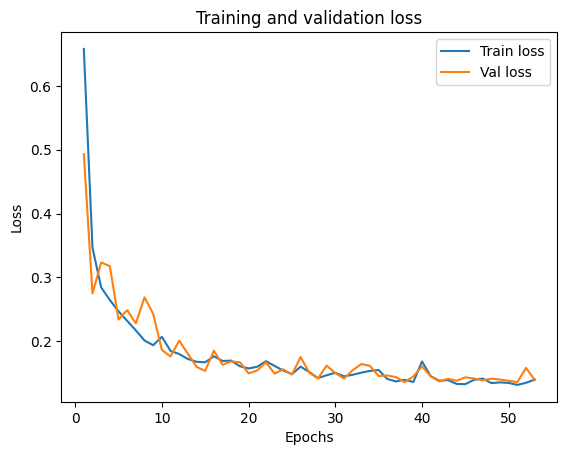

In [31]:
Visualizer.show_training_history(train_losses, val_losses)

In [31]:
model = AttentionUnetModel()
checkpoint = torch.load(f"{paths['attention unet']}/attention_unet_model_512_epoch_38.pt", weights_only=True, map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

In [32]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, train_data2)

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


{'accuracy': 0.9773664535620273,
 'dice': 0.9439000670726483,
 'iou': 0.8941271878205813,
 'loss': 0.1271527757247289}

In [33]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, test_data)

{'accuracy': 0.9755094507161308,
 'dice': 0.9424393667894251,
 'iou': 0.8913801137138816,
 'loss': 0.13327263032688813}

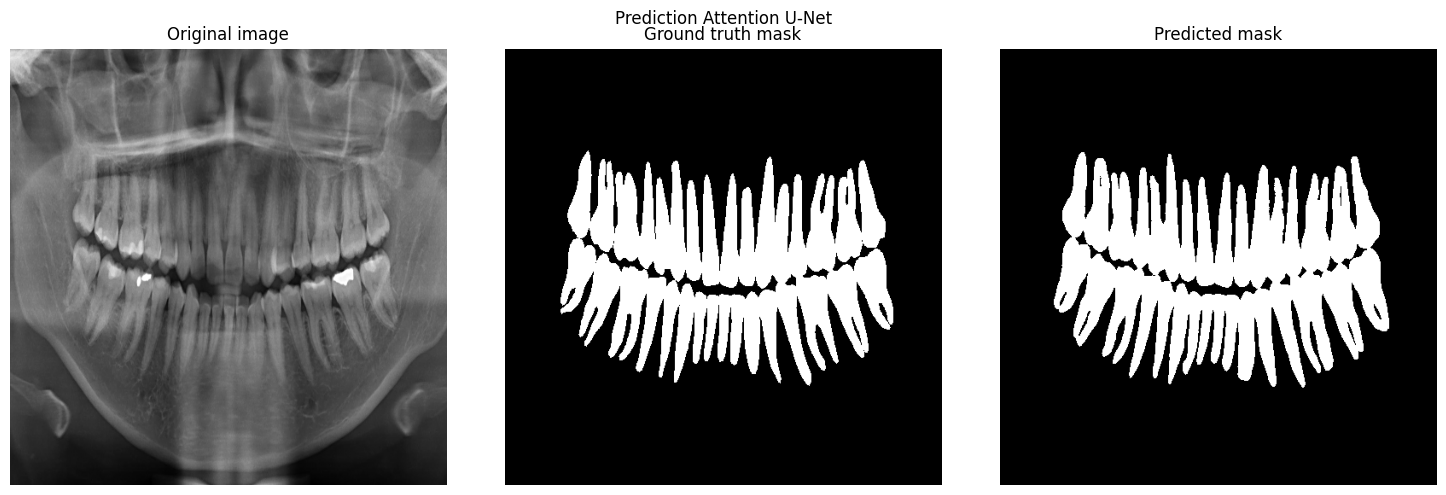

In [34]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample(model, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'Attention U-Net', is_rgb=False)

In [35]:
extractor = ToothRegionExtractor(target_size=256, padding=10)
cropped_img, cropped_mask = extractor.extract_training(image.squeeze(0).numpy(), predicted_mask.cpu().numpy().astype(np.uint8), mask.numpy().astype(np.uint8))
cropped_img, cropped_mask = torch.tensor(cropped_img), torch.tensor(cropped_mask)

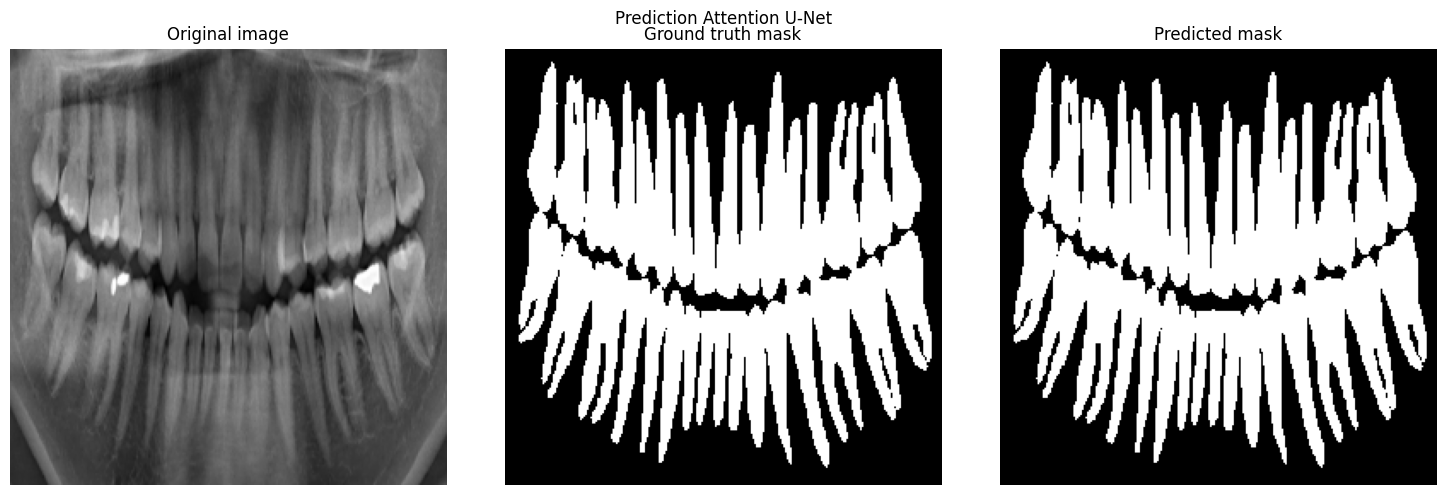

In [36]:
Visualizer.show_prediction(cropped_img.cpu(), cropped_mask.cpu(), cropped_mask.cpu(), 'Attention U-Net', is_rgb=False)

### Crop images

In [37]:
new_train_dataset = DentalDataset('caries segmentation crop/train', transform=transform, is_rgb=False, is_train=False)
new_train_data = data.DataLoader(new_train_dataset, batch_size=8, shuffle=False)

new_val_dataset = DentalDataset('caries segmentation crop/val', transform=transform, is_rgb=False, is_train=False)
new_val_data = data.DataLoader(new_val_dataset, batch_size=8, shuffle=False)

new_test_dataset = DentalDataset('caries segmentation crop/test', transform=transform, is_rgb=False, is_train=False)
new_test_data = data.DataLoader(new_test_dataset, batch_size=8, shuffle=False)

In [38]:
save_cropped_dataset(model, new_train_dataset, output_dir='caries segmentation3/train')
save_cropped_dataset(model, new_val_dataset, output_dir='caries segmentation3/val')
save_cropped_dataset(model, new_test_dataset, output_dir='caries segmentation3/test')

Processing: 100%|██████████| 100/100 [00:06<00:00, 15.01it/s]


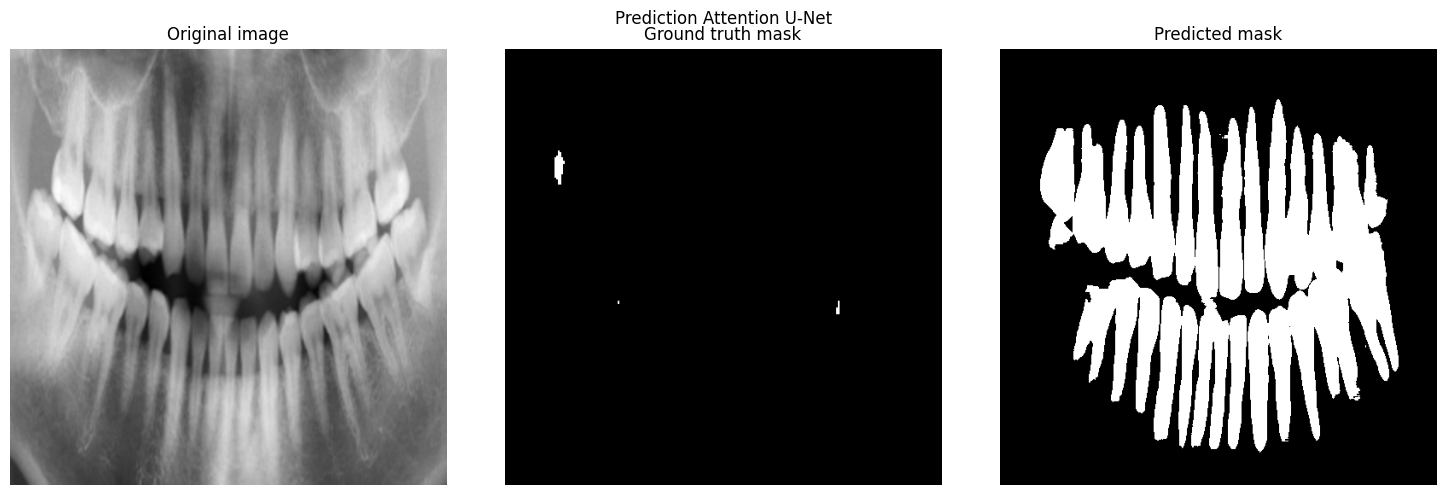

In [39]:
image, mask = load_image_and_mask('caries segmentation3/test/images/00001.png', 'caries segmentation3/test/masks/00001.png', transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample(model, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'Attention U-Net', is_rgb=False)

### U-Net: training, evaluation and inference

In [33]:
model = UnetModel()
model.to(device)

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

trainer = ModelTrainer(model, optimizer, bce_loss, dice_loss, device)
train_losses, val_losses = trainer.fit(train_data, val_data, 100, f"{paths['unet']}/unet_model.pt")

Epoch [1/100]: 100%|██████████| 39/39 [00:37<00:00,  1.05it/s, train_loss=0.8784]


val_loss: 1.3699


Epoch [2/100]: 100%|██████████| 39/39 [00:37<00:00,  1.04it/s, train_loss=0.4705]


val_loss: 0.4125


Epoch [3/100]: 100%|██████████| 39/39 [00:37<00:00,  1.05it/s, train_loss=0.3623]


...

val_loss: 0.1864


Epoch [85/100]: 100%|██████████| 39/39 [00:37<00:00,  1.03it/s, train_loss=0.1601]


val_loss: 0.1674


Epoch [86/100]: 100%|██████████| 39/39 [00:38<00:00,  1.02it/s, train_loss=0.1594]


val_loss: 0.1682


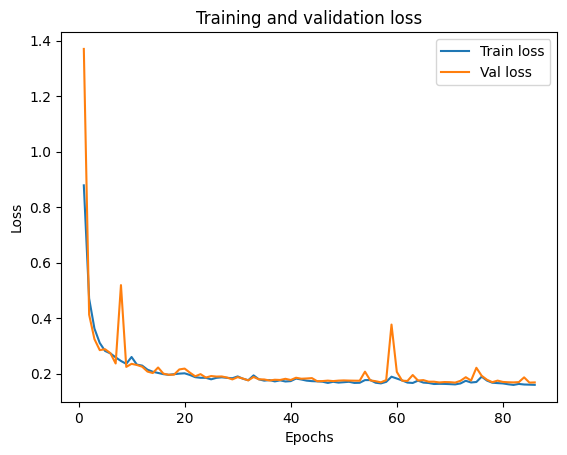

In [35]:
Visualizer.show_training_history(train_losses, val_losses)

In [126]:
model = UnetModel()
checkpoint = torch.load(f"{paths['unet']}/unet_model_epoch_71.pt", weights_only=True, map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

In [127]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, train_data2)

{'accuracy': 0.9711940227410732,
 'dice': 0.9276300714566157,
 'iou': 0.8653614490460126,
 'loss': 0.154564102490743}

In [128]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, test_data)

{'accuracy': 0.9681574039989047,
 'dice': 0.9250723322232565,
 'iou': 0.8608003258705139,
 'loss': 0.16535652511649662}

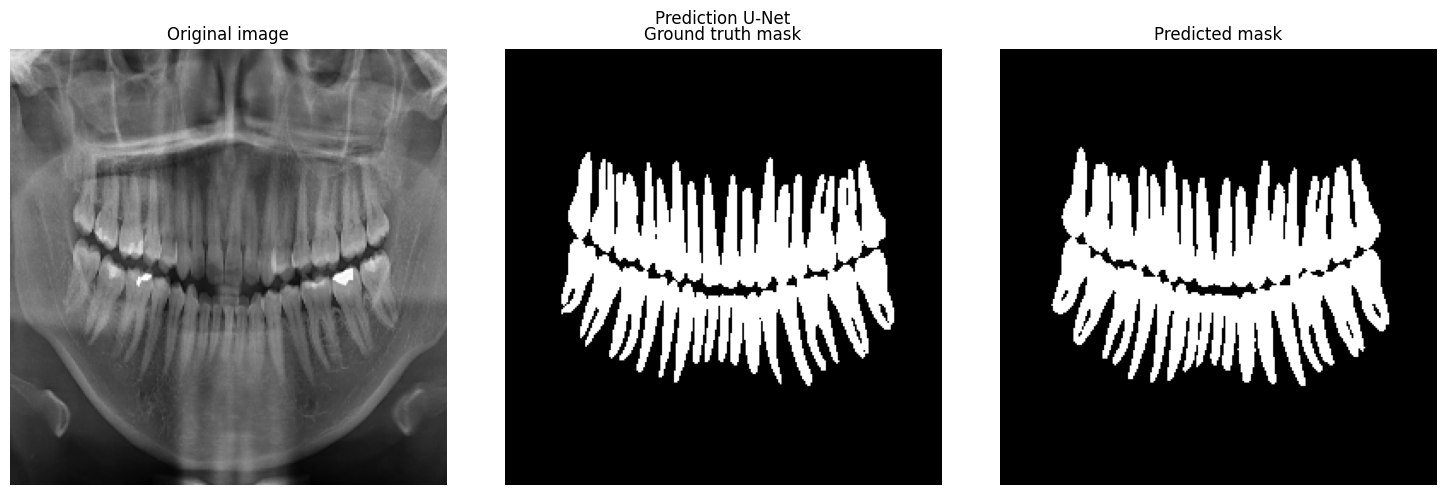

In [47]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample(model, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'U-Net', is_rgb=False)

### Residual U-Net: training, evaluation and inference

In [51]:
model = ResidualUnetModel()
model.to(device)

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

trainer = ModelTrainer(model, optimizer, bce_loss, dice_loss, device)
train_losses, val_losses = trainer.fit(train_data, val_data, 100, f"{paths['res unet']}/residual_unet_model.pt")

Epoch [1/100]: 100%|██████████| 39/39 [00:38<00:00,  1.01it/s, train_loss=0.6020]


val_loss: 0.9729


Epoch [2/100]: 100%|██████████| 39/39 [00:37<00:00,  1.03it/s, train_loss=0.3167]


val_loss: 0.3138


Epoch [3/100]: 100%|██████████| 39/39 [00:38<00:00,  1.02it/s, train_loss=0.2731]


...

val_loss: 0.2773


Epoch [48/100]: 100%|██████████| 39/39 [00:37<00:00,  1.03it/s, train_loss=0.1844]


val_loss: 0.1821


Epoch [49/100]: 100%|██████████| 39/39 [00:37<00:00,  1.03it/s, train_loss=0.1724]


val_loss: 0.1799


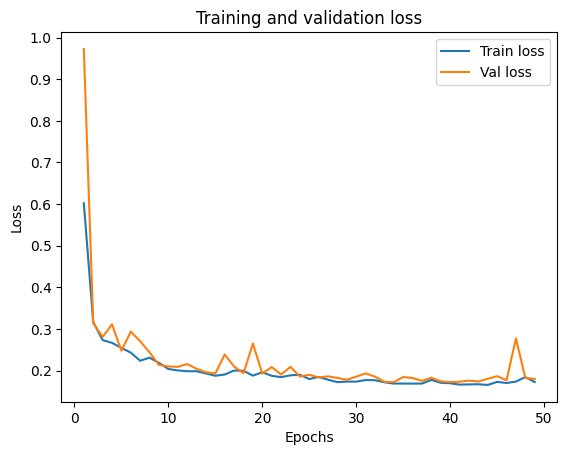

In [52]:
Visualizer.show_training_history(train_losses, val_losses)

In [129]:
model = ResidualUnetModel()
checkpoint = torch.load(f"{paths['res unet']}/residual_unet_model_epoch_33.pt", weights_only=True, map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

In [130]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, train_data2)

{'accuracy': 0.9728880662184495,
 'dice': 0.9331503327076252,
 'iou': 0.8750765491754581,
 'loss': 0.14969985874799582}

In [131]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, test_data)

{'accuracy': 0.9707855317327712,
 'dice': 0.9321430126825968,
 'iou': 0.873198025756412,
 'loss': 0.15557841625478533}

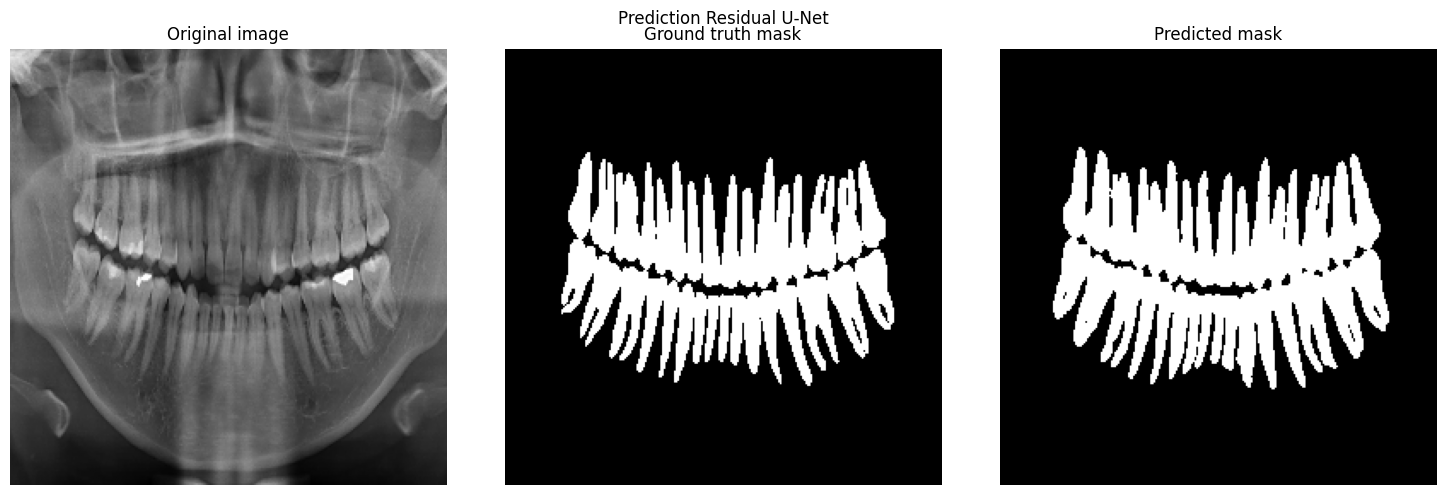

In [65]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample(model, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'Residual U-Net', is_rgb=False)

### Attention U-Net: training, evaluation and inference

In [69]:
model = AttentionUnetModel()
model.to(device)

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

trainer = ModelTrainer(model, optimizer, bce_loss, dice_loss, device)
train_losses, val_losses = trainer.fit(train_data, val_data, 100, f"{paths['attention unet']}/attention_unet_model.pt")

Epoch [1/100]: 100%|██████████| 39/39 [00:38<00:00,  1.02it/s, train_loss=0.8468]


val_loss: 1.0370


Epoch [2/100]: 100%|██████████| 39/39 [00:39<00:00,  1.00s/it, train_loss=0.4794]


val_loss: 0.4262


Epoch [3/100]: 100%|██████████| 39/39 [00:38<00:00,  1.01it/s, train_loss=0.3484]


...

val_loss: 0.1918


Epoch [77/100]: 100%|██████████| 39/39 [00:38<00:00,  1.01it/s, train_loss=0.1710]


val_loss: 0.1733


Epoch [78/100]: 100%|██████████| 39/39 [00:39<00:00,  1.01s/it, train_loss=0.1655]


val_loss: 0.1783


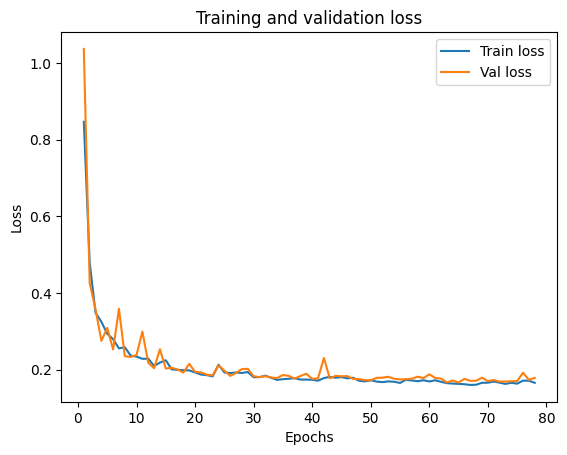

In [70]:
Visualizer.show_training_history(train_losses, val_losses)

In [132]:
model = AttentionUnetModel()
checkpoint = torch.load(f"{paths['attention unet']}/attention_unet_model_epoch_63.pt", weights_only=True, map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

In [133]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, train_data2)

{'accuracy': 0.9736496851994441,
 'dice': 0.9347327443269583,
 'iou': 0.8777743944754968,
 'loss': 0.1447263696254828}

In [134]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, test_data)

{'accuracy': 0.9708416329489814,
 'dice': 0.9317638940281339,
 'iou': 0.8725102874967787,
 'loss': 0.1546968768040339}

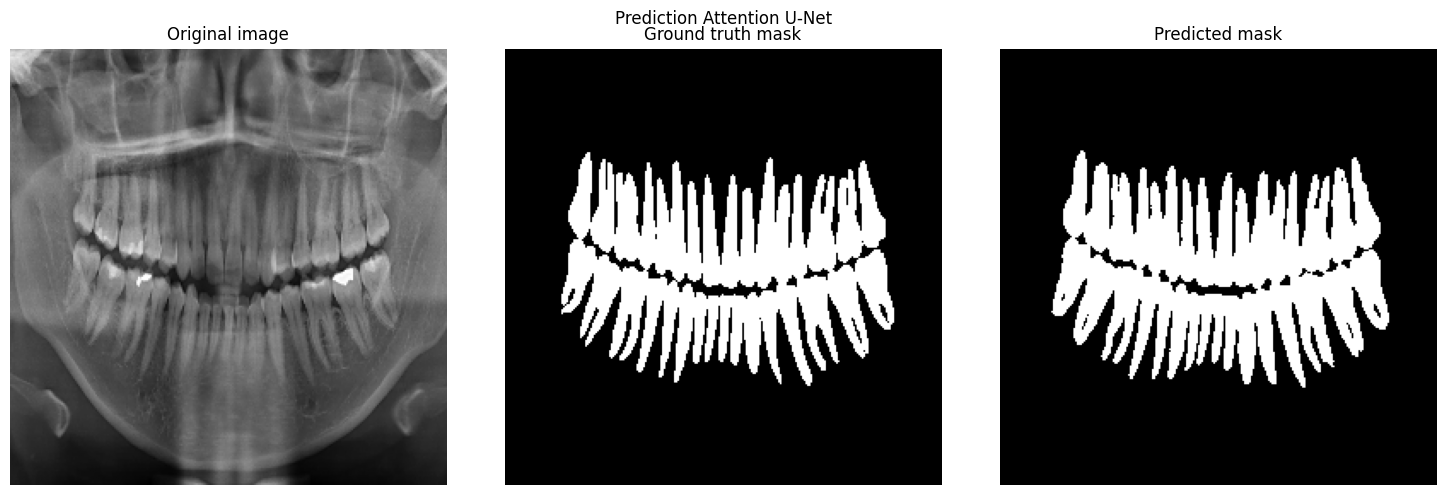

In [74]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample(model, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'Attention U-Net', is_rgb=False)

### Residual attention U-Net: training, evaluation and inference

In [29]:
model = ResidualAttentionUnetModel()
model.to(device)

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

trainer = ModelTrainer(model, optimizer, bce_loss, dice_loss, device)
train_losses, val_losses = trainer.fit(train_data, val_data, 100, f"{paths['res attention unet']}/residual_attention_unet_model.pt")

Epoch [1/100]: 100%|██████████| 39/39 [00:37<00:00,  1.04it/s, train_loss=0.5844]


val_loss: 0.6792


Epoch [2/100]: 100%|██████████| 39/39 [00:36<00:00,  1.07it/s, train_loss=0.3163]


val_loss: 0.4440


Epoch [3/100]: 100%|██████████| 39/39 [00:36<00:00,  1.07it/s, train_loss=0.2743]


...

val_loss: 0.1703


Epoch [64/100]: 100%|██████████| 39/39 [00:42<00:00,  1.08s/it, train_loss=0.1630]


val_loss: 0.1733


Epoch [65/100]: 100%|██████████| 39/39 [00:40<00:00,  1.03s/it, train_loss=0.1640]


val_loss: 0.1711


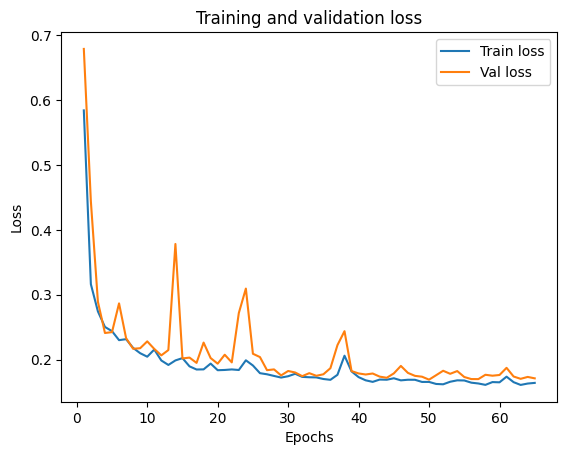

In [30]:
Visualizer.show_training_history(train_losses, val_losses)

In [135]:
model = ResidualAttentionUnetModel()
checkpoint = torch.load(f"{paths['res attention unet']}/residual_attention_unet_model_epoch_50.pt", weights_only=True, map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

In [136]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, train_data)

{'accuracy': 0.969808700757149,
 'dice': 0.9253849616417518,
 'iou': 0.8615605051700885,
 'loss': 0.1624804261403206}

In [137]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, test_data)

{'accuracy': 0.9694174528121948,
 'dice': 0.9290793273184035,
 'iou': 0.8677760627534654,
 'loss': 0.1603761398129993}

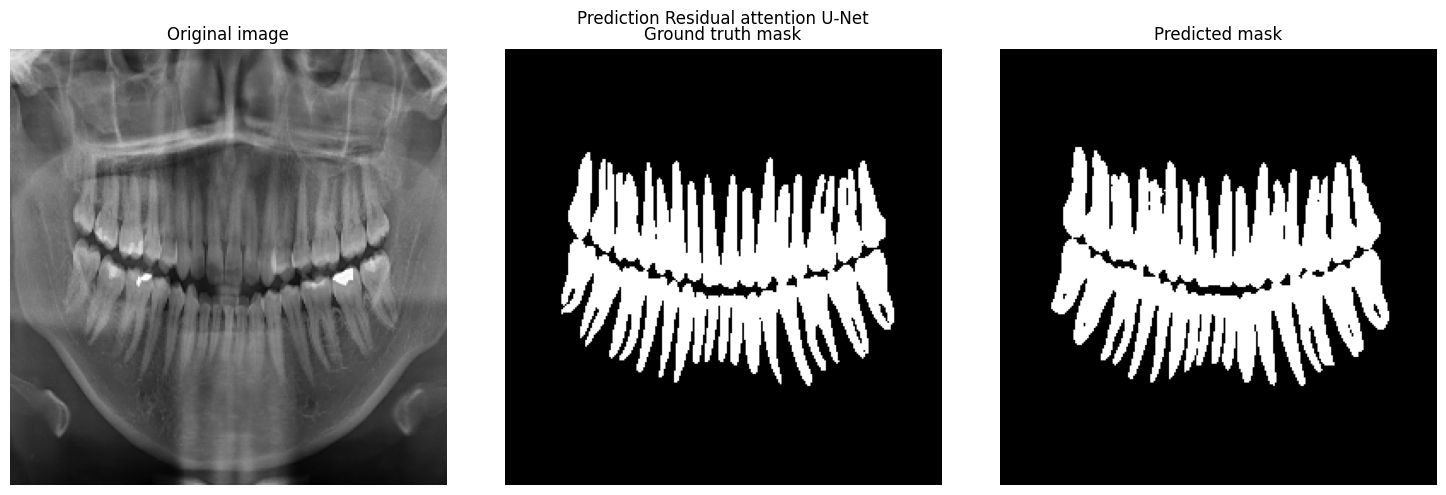

In [33]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample(model, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'Residual attention U-Net', is_rgb=False)

### R2 U-Net: training, evaluation and inference

In [97]:
model = R2UnetModel(is_dropout=True, dropout_rate=0.2)
model.to(device)

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

trainer = ModelTrainer(model, optimizer, bce_loss, dice_loss, device)
train_losses, val_losses = trainer.fit(train_data, val_data, 100, f"{paths['r2 unet']}/r2_unet_model.pt")

Epoch [1/100]: 100%|██████████| 39/39 [00:17<00:00,  2.27it/s, train_loss=0.6483]


val_loss: 1.4668


Epoch [2/100]: 100%|██████████| 39/39 [00:17<00:00,  2.28it/s, train_loss=0.3524]


val_loss: 1.2566


Epoch [3/100]: 100%|██████████| 39/39 [00:17<00:00,  2.29it/s, train_loss=0.3151]


...

val_loss: 0.3046


Epoch [42/100]: 100%|██████████| 39/39 [00:18<00:00,  2.08it/s, train_loss=0.1792]


val_loss: 0.5131


Epoch [43/100]: 100%|██████████| 39/39 [00:18<00:00,  2.08it/s, train_loss=0.1789]


val_loss: 0.3512


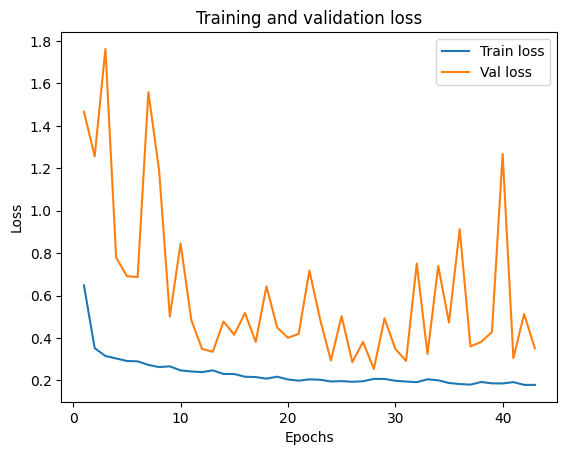

In [98]:
Visualizer.show_training_history(train_losses, val_losses)

In [111]:
model = R2UnetModel()
checkpoint = torch.load(f"{paths['r2 unet']}/r2_unet_model_epoch_28.pt", weights_only=True, map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

In [112]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, train_data2)

{'accuracy': 0.9598319958417844,
 'dice': 0.8992871535130036,
 'iou': 0.8183599297816937,
 'loss': 0.22750116846500298}

In [113]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, test_data)

{'accuracy': 0.958480609787835,
 'dice': 0.9036238590876261,
 'iou': 0.8248289095030891,
 'loss': 0.2247128188610077}

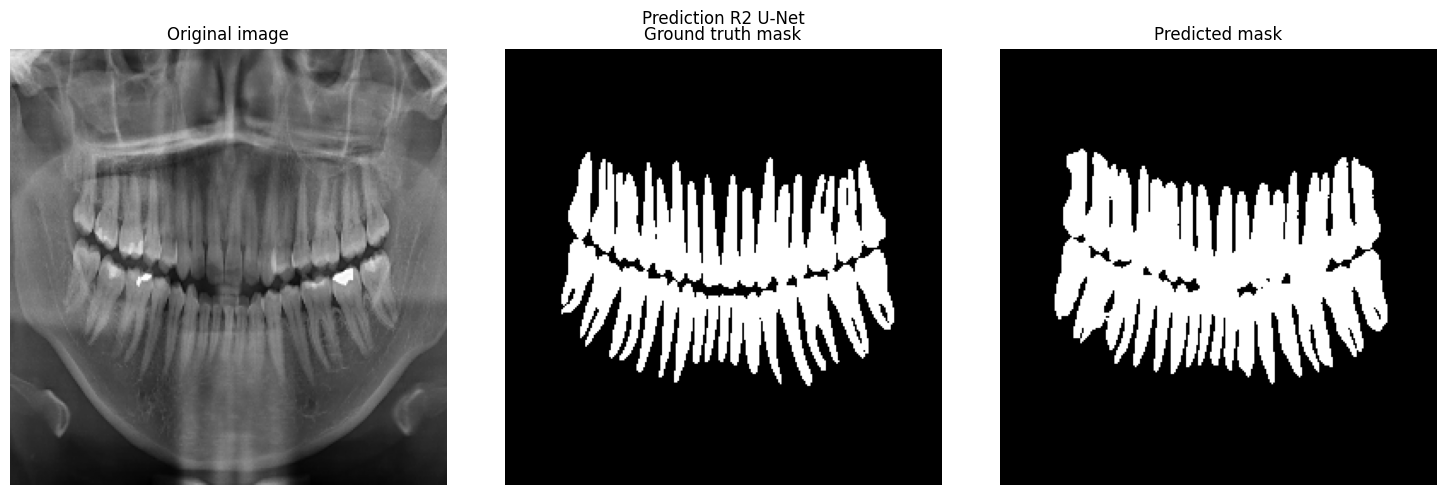

In [114]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample(model, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'R2 U-Net', is_rgb=False)

### U-Net++: training, evaluation and inference

In [31]:
model = UnetPlusPlusModel(deep_supervision=True)
model.to(device)

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

trainer = ModelTrainer(model, optimizer, bce_loss, dice_loss, device, deep_supervision=True)
train_losses, val_losses = trainer.fit(train_data, val_data, 100, f"{paths['unet++']}/unet_plus_plus_model.pt")

Epoch [1/100]: 100%|██████████| 39/39 [00:13<00:00,  2.79it/s, train_loss=0.8946]


val_loss: 0.9649


Epoch [2/100]: 100%|██████████| 39/39 [00:13<00:00,  2.82it/s, train_loss=0.5433]


val_loss: 0.4143


Epoch [3/100]: 100%|██████████| 39/39 [00:13<00:00,  2.81it/s, train_loss=0.4059]


...

val_loss: 0.1915


Epoch [69/100]: 100%|██████████| 39/39 [00:13<00:00,  2.80it/s, train_loss=0.1805]


val_loss: 0.1865


Epoch [70/100]: 100%|██████████| 39/39 [00:13<00:00,  2.81it/s, train_loss=0.1795]


val_loss: 0.1904


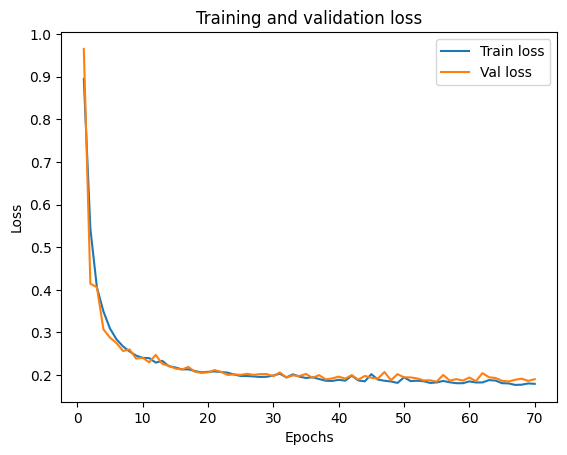

In [32]:
Visualizer.show_training_history(train_losses, val_losses)

In [142]:
model = UnetPlusPlusModel(deep_supervision=True)
checkpoint = torch.load(f"{paths['unet++']}/unet_plus_plus_model_epoch_55.pt", weights_only=True, map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.deep_supervision = False

In [143]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, train_data2)

{'accuracy': 0.9692999521891276,
 'dice': 0.9233657121658325,
 'iou': 0.8579616684180039,
 'loss': 0.16221698354452085}

In [144]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, test_data)

{'accuracy': 0.9658791091707017,
 'dice': 0.9199414054552714,
 'iou': 0.8519451022148132,
 'loss': 0.17489521702130637}

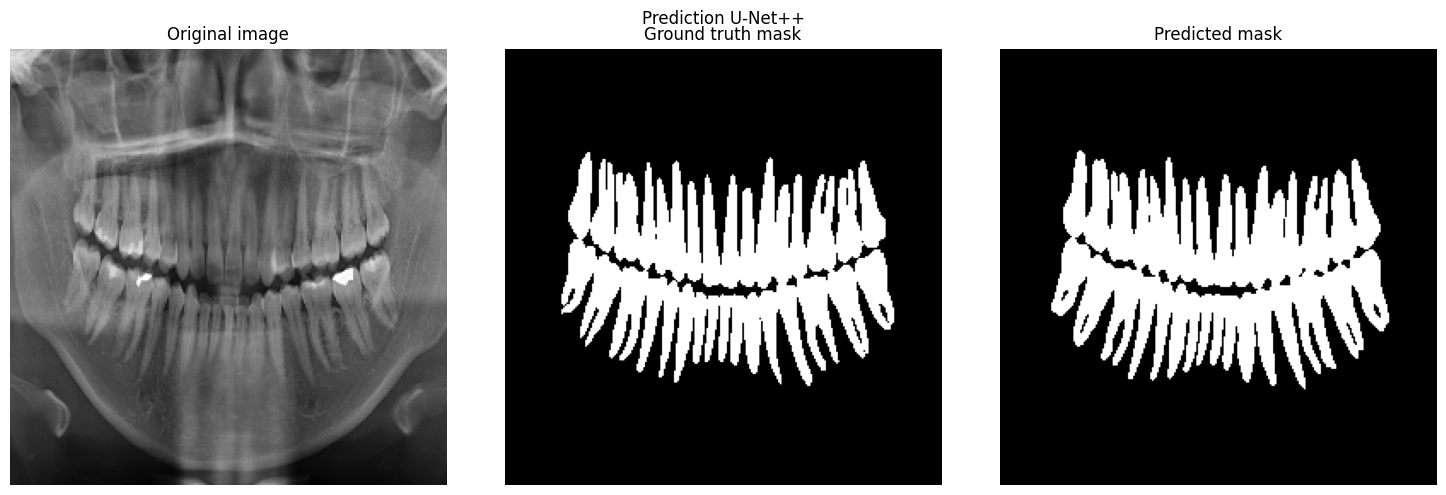

In [44]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample(model, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'U-Net++', is_rgb=False)

### U-Net 3+: training, evaluation and inference

In [29]:
model = Unet3PlusModel()
model.to(device)

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

trainer = ModelTrainer(model, optimizer, bce_loss, dice_loss, device)
train_losses, val_losses = trainer.fit(train_data, val_data, 100, f"{paths['unet3+']}/unet_3plus_model.pt")

Epoch [1/100]: 100%|██████████| 39/39 [00:56<00:00,  1.44s/it, train_loss=0.8093]


val_loss: 1.3947


Epoch [2/100]: 100%|██████████| 39/39 [00:55<00:00,  1.43s/it, train_loss=0.4501]


val_loss: 0.3263


Epoch [3/100]: 100%|██████████| 39/39 [00:55<00:00,  1.42s/it, train_loss=0.3286]


...

val_loss: 0.1730


Epoch [81/100]: 100%|██████████| 39/39 [00:56<00:00,  1.44s/it, train_loss=0.1640]


val_loss: 0.1794


Epoch [82/100]: 100%|██████████| 39/39 [00:56<00:00,  1.44s/it, train_loss=0.1679]


val_loss: 0.1748


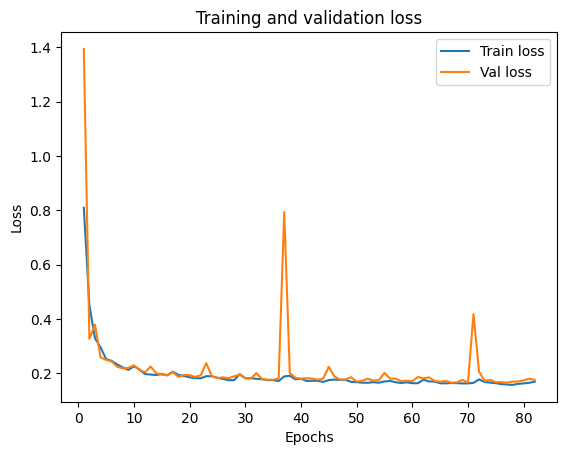

In [30]:
Visualizer.show_training_history(train_losses, val_losses)

In [145]:
model = Unet3PlusModel()
checkpoint = torch.load(f"{paths['unet3+']}/unet_3plus_model_epoch_50.pt", weights_only=True, map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

In [146]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, train_data2)

{'accuracy': 0.973785889454377,
 'dice': 0.9355627435904282,
 'iou': 0.8792556478427007,
 'loss': 0.14514583693100855}

In [147]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, test_data)

{'accuracy': 0.9714501235220168,
 'dice': 0.933519634935591,
 'iou': 0.8755658666292826,
 'loss': 0.15257105396853554}

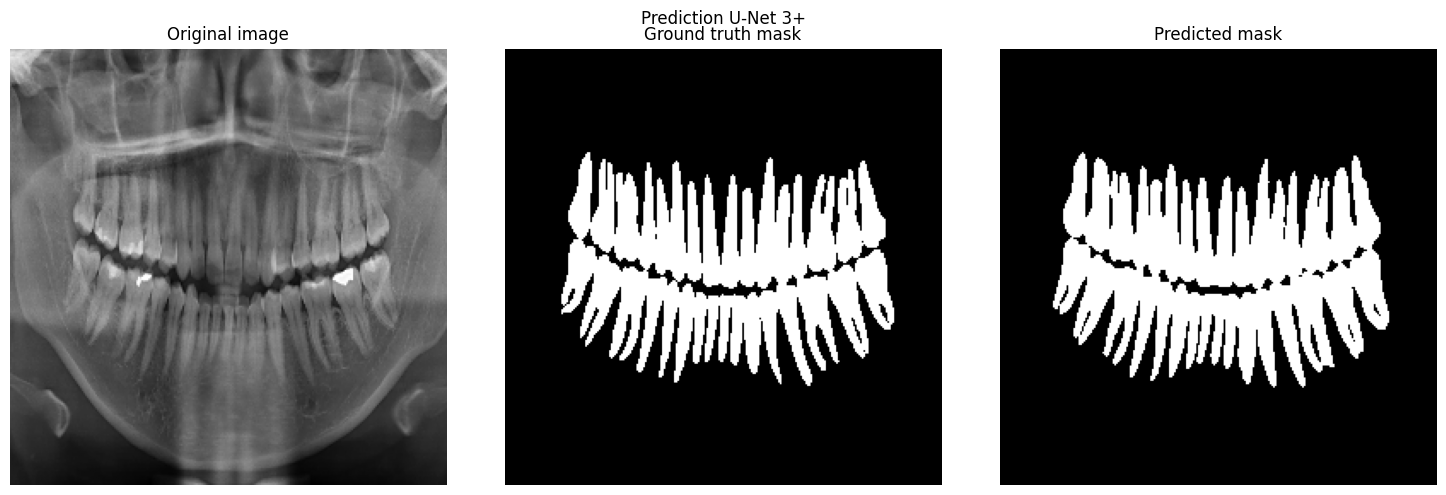

In [37]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample(model, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'U-Net 3+', is_rgb=False)

### SE U-Net: training, evaluation and inference

In [57]:
model = SeUnetModel()
model.to(device)

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

trainer = ModelTrainer(model, optimizer, bce_loss, dice_loss, device)
train_losses, val_losses = trainer.fit(train_data, val_data, 100, f"{paths['se unet']}/se_unet_model.pt")

Epoch [1/100]: 100%|██████████| 39/39 [00:09<00:00,  3.95it/s, train_loss=0.8596]


val_loss: 1.1290


Epoch [2/100]: 100%|██████████| 39/39 [00:08<00:00,  4.35it/s, train_loss=0.5350]


val_loss: 0.4268


Epoch [3/100]: 100%|██████████| 39/39 [00:09<00:00,  4.13it/s, train_loss=0.3986]


...

val_loss: 0.1682


Epoch [82/100]: 100%|██████████| 39/39 [00:12<00:00,  3.19it/s, train_loss=0.1581]


val_loss: 0.1686


Epoch [83/100]: 100%|██████████| 39/39 [00:11<00:00,  3.34it/s, train_loss=0.1577]


val_loss: 0.1663


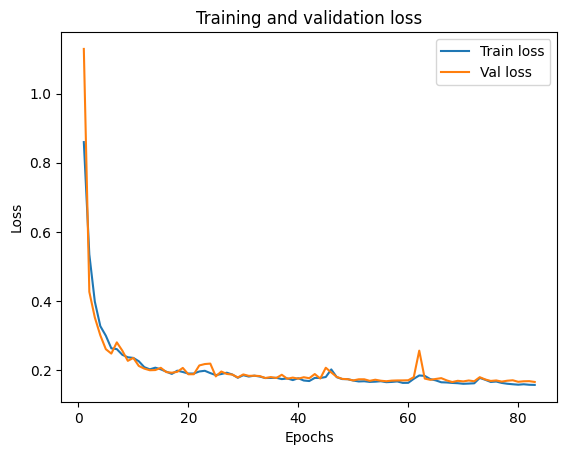

In [58]:
Visualizer.show_training_history(train_losses, val_losses)

In [59]:
model = SeUnetModel()
checkpoint = torch.load(f"{paths['se unet']}/se_unet_model_epoch_68.pt", weights_only=True, map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

In [60]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, train_data2)

{'accuracy': 0.9720073846670297,
 'dice': 0.931087464858324,
 'iou': 0.871350673528818,
 'loss': 0.15474873055250216}

In [61]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, test_data)

{'accuracy': 0.9691342578993903,
 'dice': 0.9282077749570211,
 'iou': 0.8662471175193787,
 'loss': 0.16470870872338614}

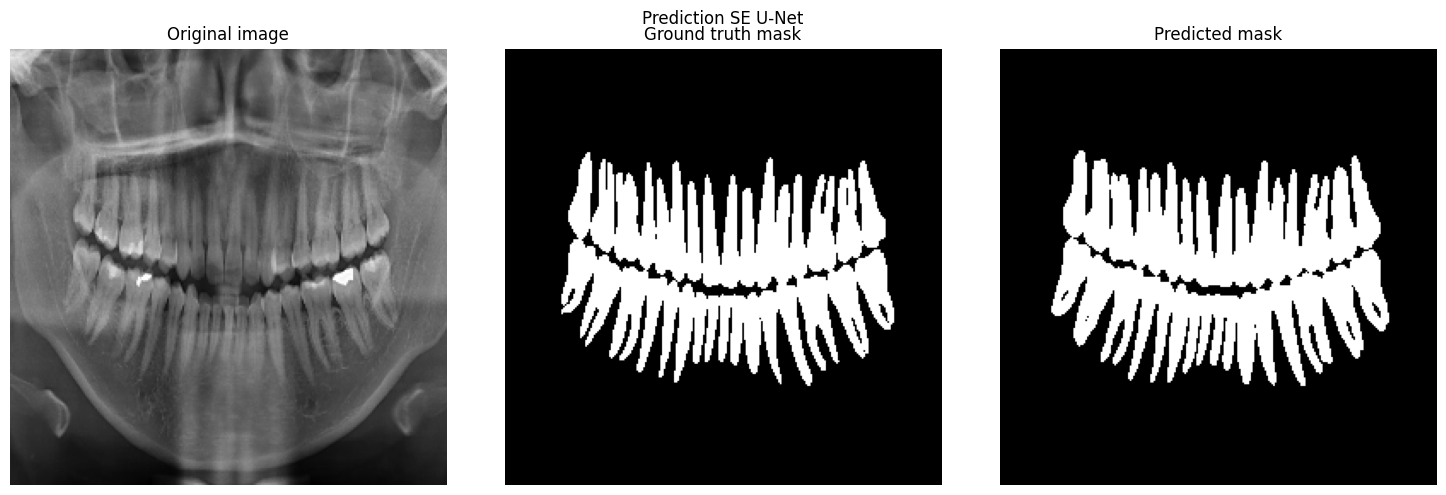

In [62]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample(model, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'SE U-Net', is_rgb=False)

### Dense U-Net: training, evaluation and inference

In [31]:
model = DenseUnetModel()
model.to(device)

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

trainer = ModelTrainer(model, optimizer, bce_loss, dice_loss, device)
train_losses, val_losses = trainer.fit(train_data, val_data, 100, f"{paths['dense unet']}/dense_unet_model.pt")

Epoch [1/100]: 100%|██████████| 78/78 [00:27<00:00,  2.83it/s, train_loss=0.4722]


val_loss: 0.3132


Epoch [2/100]: 100%|██████████| 78/78 [00:27<00:00,  2.87it/s, train_loss=0.2945]


val_loss: 0.2924


Epoch [3/100]: 100%|██████████| 78/78 [00:27<00:00,  2.85it/s, train_loss=0.2705]


...

val_loss: 0.1673


Epoch [84/100]: 100%|██████████| 78/78 [00:27<00:00,  2.81it/s, train_loss=0.1640]


val_loss: 0.1686


Epoch [85/100]: 100%|██████████| 78/78 [00:28<00:00,  2.70it/s, train_loss=0.1621]


val_loss: 0.1671


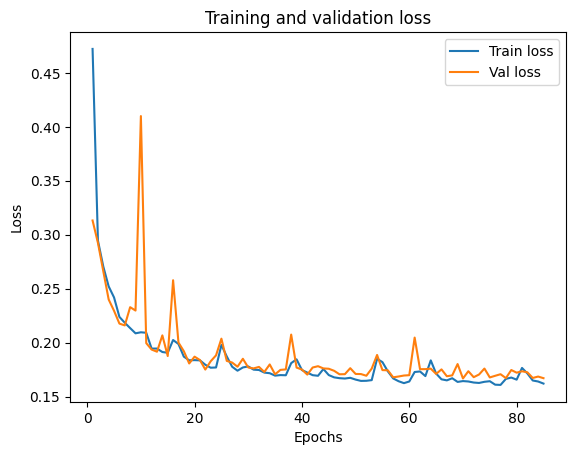

In [32]:
Visualizer.show_training_history(train_losses, val_losses)

In [33]:
model = DenseUnetModel()
checkpoint = torch.load(f"{paths['dense unet']}/dense_unet_model_epoch_70.pt", weights_only=True, map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

In [34]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, train_data2)

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


{'accuracy': 0.9744793818547175,
 'dice': 0.9371357583082639,
 'iou': 0.8820281899892367,
 'loss': 0.14080698090868118}

In [35]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, test_data)

{'accuracy': 0.9717400810297798,
 'dice': 0.9341074859394747,
 'iou': 0.8766271962839014,
 'loss': 0.15053549759528217}

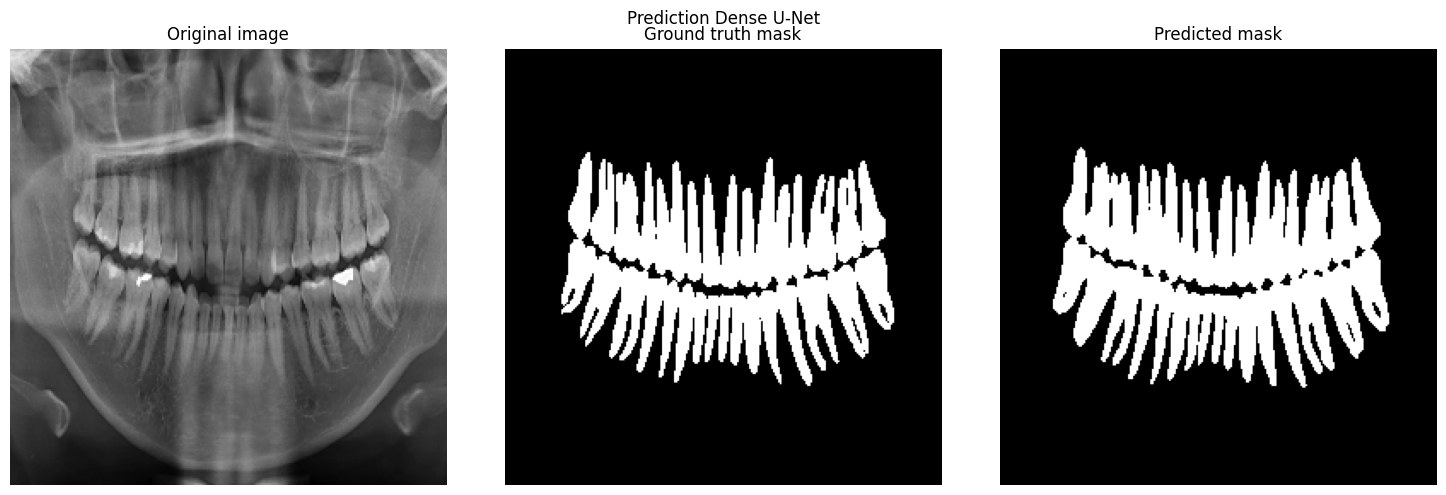

In [39]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample(model, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'Dense U-Net', is_rgb=False)

### DeepLabV3+: training, evaluation and inference

In [29]:
model = DeepLabV3PlusModel()
model.to(device)

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

trainer = ModelTrainer(model, optimizer, bce_loss, dice_loss, device)
train_losses, val_losses = trainer.fit(train_data, val_data, 100, f"{paths['deeplabv3+']}/deeplabv3plus_model.pt")

Epoch [1/100]: 100%|██████████| 39/39 [00:05<00:00,  7.17it/s, train_loss=1.1949]


val_loss: 0.3961


Epoch [2/100]: 100%|██████████| 39/39 [00:04<00:00,  7.98it/s, train_loss=0.3720]


val_loss: 0.3377


Epoch [3/100]: 100%|██████████| 39/39 [00:04<00:00,  7.87it/s, train_loss=0.3237]


...

val_loss: 0.2397


Epoch [47/100]: 100%|██████████| 39/39 [00:04<00:00,  7.83it/s, train_loss=0.2384]


val_loss: 0.2315


Epoch [48/100]: 100%|██████████| 39/39 [00:05<00:00,  7.75it/s, train_loss=0.2377]


val_loss: 0.2331


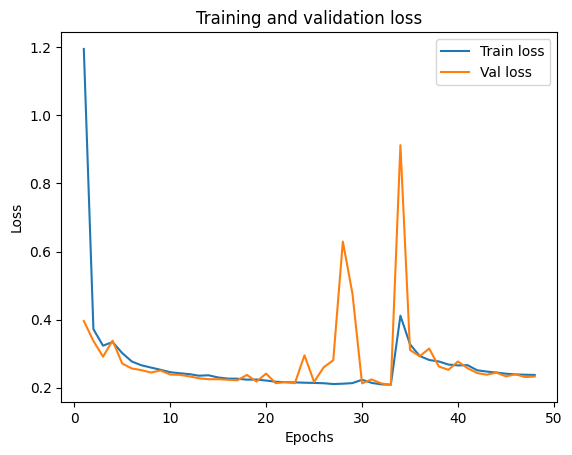

In [30]:
Visualizer.show_training_history(train_losses, val_losses)

In [31]:
model = DeepLabV3PlusModel()
checkpoint = torch.load(f"{paths['deeplabv3+']}/deeplabv3plus_model_epoch_33.pt", weights_only=True, map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

In [32]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, train_data2)

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


{'accuracy': 0.9617318373460036,
 'dice': 0.9076021191401359,
 'iou': 0.8312282791504493,
 'loss': 0.20515821950557905}

In [33]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, test_data)

{'accuracy': 0.9589949581358168,
 'dice': 0.9069049093458388,
 'iou': 0.8299231131871542,
 'loss': 0.21333184010452694}

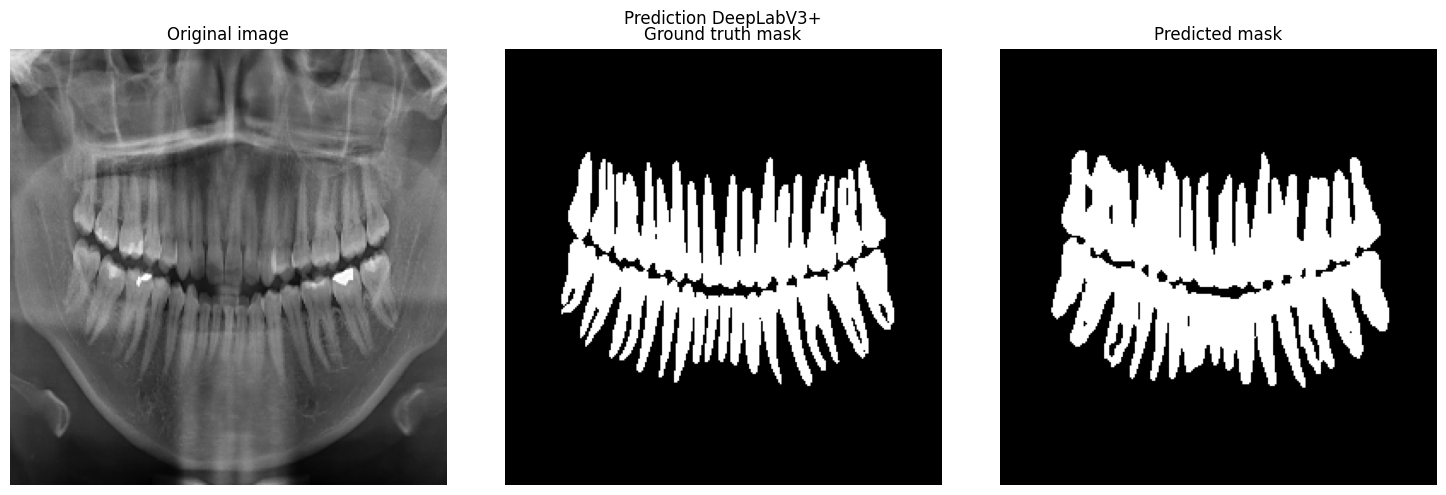

In [34]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample(model, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'DeepLabV3+', is_rgb=False)

### Multiple models: evaluation and inference

In [115]:
model1 = DenseUnetModel()
checkpoint1 = torch.load(f"{paths['dense unet']}/dense_unet_model_epoch_70.pt", weights_only=True, map_location=torch.device(device))
model1.load_state_dict(checkpoint1['model_state_dict'])
model1 = model1.to(device)

model2 = Unet3PlusModel()
checkpoint2 = torch.load(f"{paths['unet3+']}/unet_3plus_model_epoch_50.pt", weights_only=True, map_location=torch.device(device))
model2.load_state_dict(checkpoint2['model_state_dict'])
model2 = model2.to(device)

model3 = AttentionUnetModel()
checkpoint3 = torch.load(f"{paths['attention unet']}/attention_unet_model_epoch_63.pt", weights_only=True, map_location=torch.device(device))
model3.load_state_dict(checkpoint3['model_state_dict'])
model3 = model3.to(device)

models = [model1, model2, model3]

In [116]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_models(models, train_data2)

{'accuracy': 0.9746778439252805,
 'dice': 0.937675477602543,
 'iou': 0.8829739002081064}

In [117]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_models(models, test_data)

{'accuracy': 0.9721340735753378,
 'dice': 0.9350761373837789,
 'iou': 0.8783100446065267}

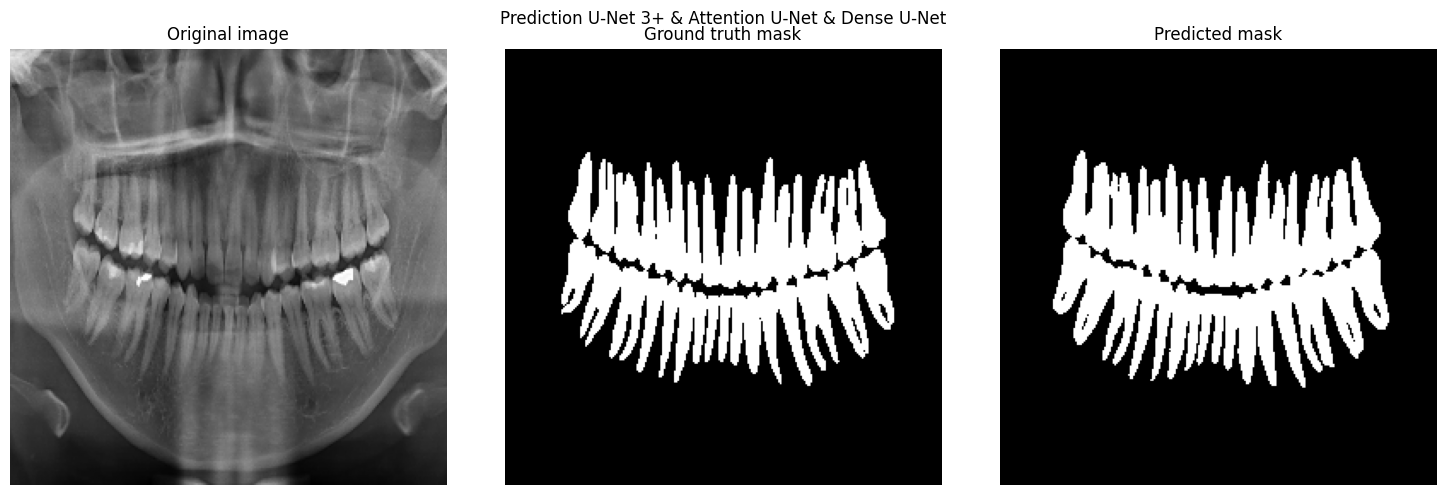

In [118]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample_for_models(models, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'U-Net 3+ & Attention U-Net & Dense U-Net', is_rgb=False)

### All predictions

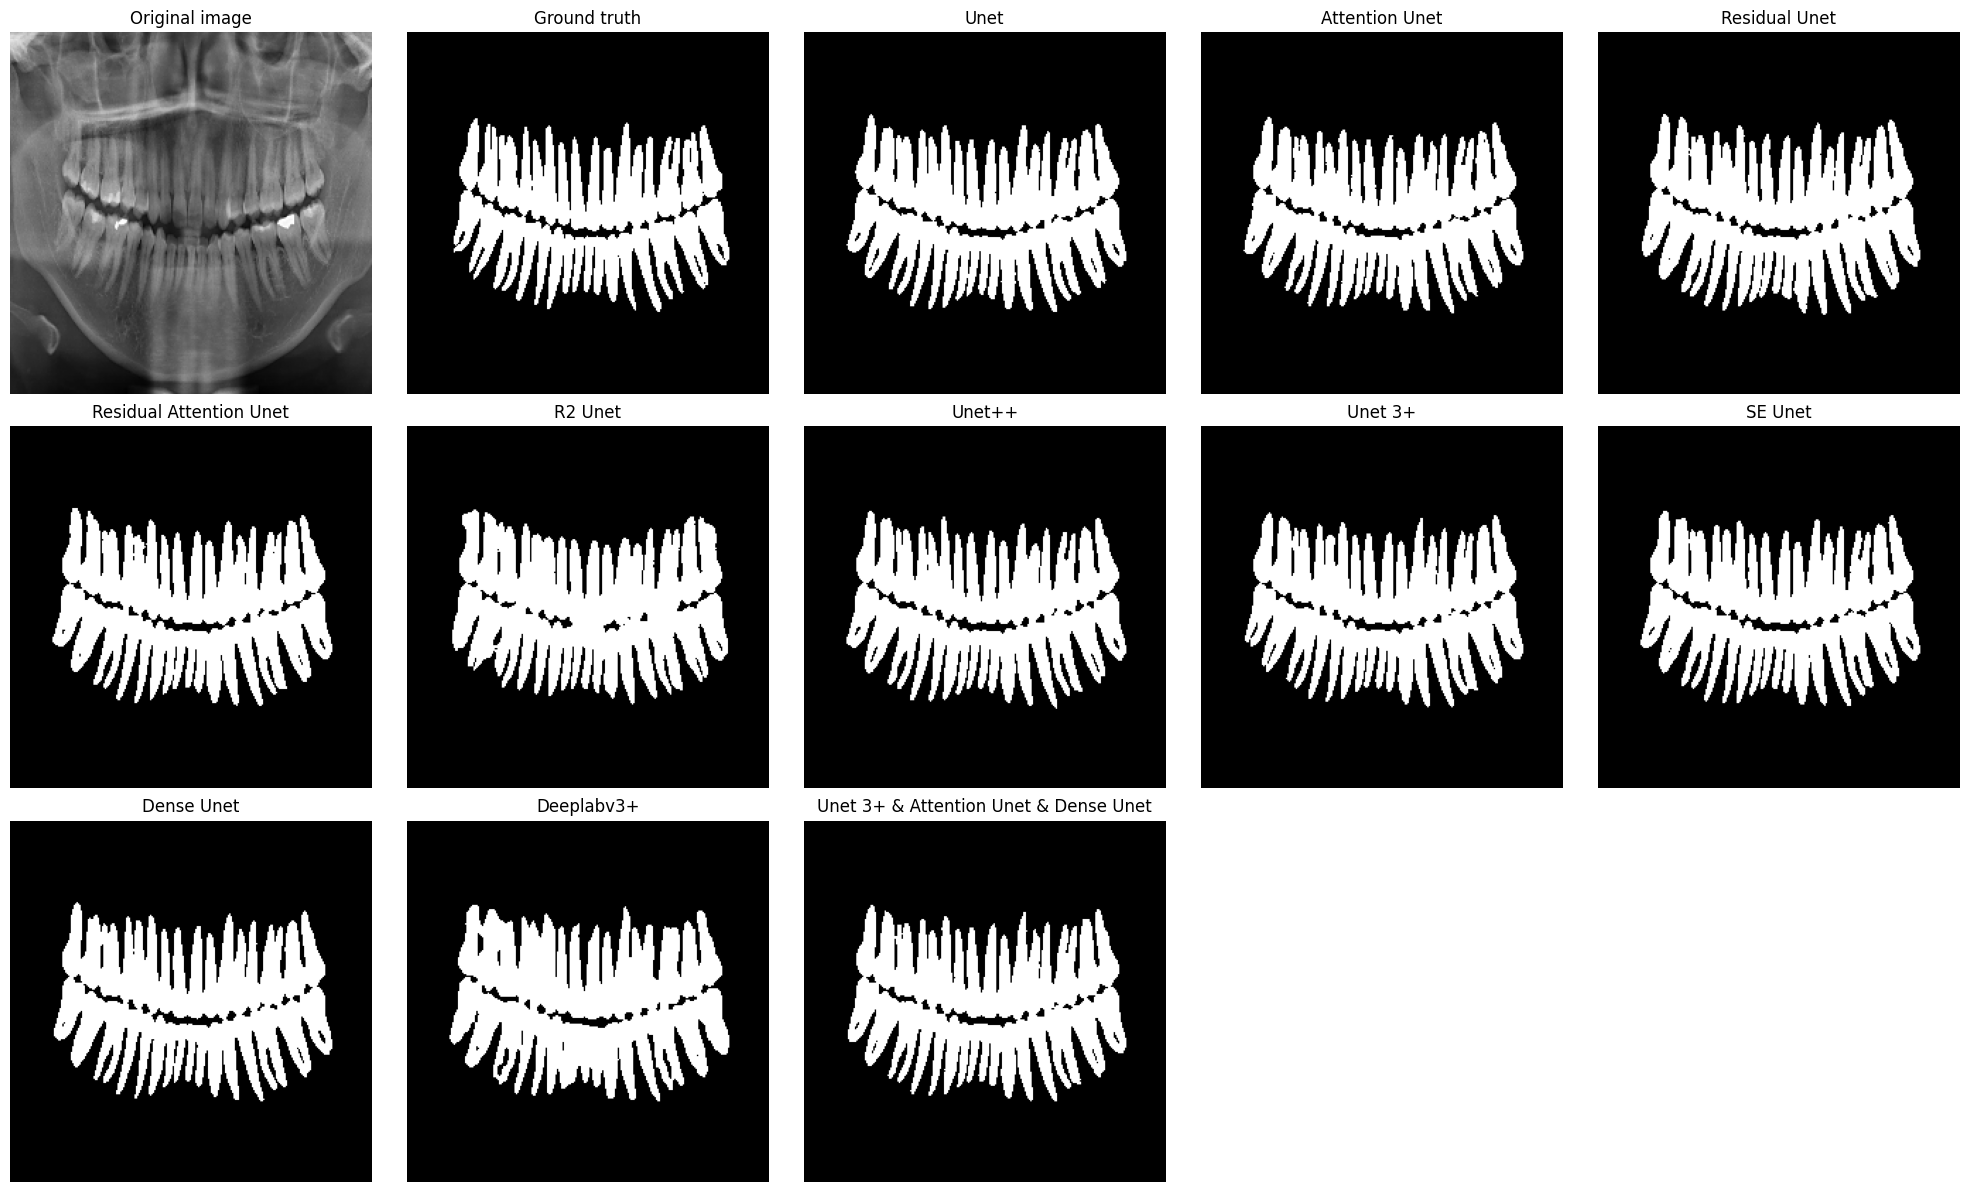

In [32]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)
predicted_masks = []
titles = ['Unet', 'Attention Unet', 'Residual Unet', 'Residual Attention Unet', 
          'R2 Unet', 'Unet++', 'Unet 3+', 'SE Unet', 'Dense Unet', 
          'Deeplabv3+', 'Unet 3+ & Attention Unet & Dense Unet']

model1 = UnetModel()
checkpoint1 = torch.load(f"{paths['unet']}/unet_model_epoch_71.pt", weights_only=True, map_location=torch.device(device))
model1.load_state_dict(checkpoint1['model_state_dict'])
model1 = model1.to(device)
predicted_masks.append(ModelPredictor.predict_sample(model1, image, device))


model2 = AttentionUnetModel()
checkpoint2 = torch.load(f"{paths['attention unet']}/attention_unet_model_epoch_63.pt", weights_only=True, map_location=torch.device(device))
model2.load_state_dict(checkpoint2['model_state_dict'])
model2 = model2.to(device)
predicted_masks.append(ModelPredictor.predict_sample(model2, image, device))


model3 = ResidualUnetModel()
checkpoint3 = torch.load(f"{paths['res unet']}/residual_unet_model_epoch_33.pt", weights_only=True, map_location=torch.device(device))
model3.load_state_dict(checkpoint3['model_state_dict'])
model3 = model3.to(device)
predicted_masks.append(ModelPredictor.predict_sample(model3, image, device))


model4 = ResidualAttentionUnetModel()
checkpoint4 = torch.load(f"{paths['res attention unet']}/residual_attention_unet_model_epoch_50.pt", weights_only=True, map_location=torch.device(device))
model4.load_state_dict(checkpoint4['model_state_dict'])
model4 = model4.to(device)
predicted_masks.append(ModelPredictor.predict_sample(model4, image, device))


model5 = R2UnetModel()
checkpoint5 = torch.load(f"{paths['r2 unet']}/r2_unet_model_epoch_28.pt", weights_only=True, map_location=torch.device(device))
model5.load_state_dict(checkpoint5['model_state_dict'])
model5 = model5.to(device)
predicted_masks.append(ModelPredictor.predict_sample(model5, image, device))


model6 = UnetPlusPlusModel(deep_supervision=True)
checkpoint6 = torch.load(f"{paths['unet++']}/unet_plus_plus_model_epoch_55.pt", weights_only=True, map_location=torch.device(device))
model6.load_state_dict(checkpoint6['model_state_dict'])
model6 = model6.to(device)
model6.deep_supervision = False
predicted_masks.append(ModelPredictor.predict_sample(model6, image, device))


model7 = Unet3PlusModel()
checkpoint7 = torch.load(f"{paths['unet3+']}/unet_3plus_model_epoch_50.pt", weights_only=True, map_location=torch.device(device))
model7.load_state_dict(checkpoint7['model_state_dict'])
model7 = model7.to(device)
predicted_masks.append(ModelPredictor.predict_sample(model7, image, device))


model8 = SeUnetModel()
checkpoint8 = torch.load(f"{paths['se unet']}/se_unet_model_epoch_68.pt", weights_only=True, map_location=torch.device(device))
model8.load_state_dict(checkpoint8['model_state_dict'])
model8 = model8.to(device)
predicted_masks.append(ModelPredictor.predict_sample(model8, image, device))


model9 = DenseUnetModel()
checkpoint9 = torch.load(f"{paths['dense unet']}/dense_unet_model_epoch_70.pt", weights_only=True, map_location=torch.device(device))
model9.load_state_dict(checkpoint9['model_state_dict'])
model9 = model9.to(device)
predicted_masks.append(ModelPredictor.predict_sample(model9, image, device))


model10 = DeepLabV3PlusModel()
checkpoint10 = torch.load(f"{paths['deeplabv3+']}/deeplabv3plus_model_epoch_33.pt", weights_only=True, map_location=torch.device(device))
model10.load_state_dict(checkpoint10['model_state_dict'])
model10 = model10.to(device)
predicted_masks.append(ModelPredictor.predict_sample(model10, image, device))


predicted_masks.append(ModelPredictor.predict_sample_for_models([model2, model3, model7], image, device))

predicted_masks = [mask.cpu() for mask in predicted_masks]

Visualizer.show_predictions(image.squeeze(0).cpu(), mask.cpu(), predicted_masks, titles, ncols=5)

## Caries segmentation

In [29]:
device = get_device()

dataset_train_path = "caries segmentation3/train"
dataset_test_path = "caries segmentation3/test"
dataset_val_path = "caries segmentation3/val"
test_img_path = "caries segmentation3/test/images/00021.png"
test_mask_path = "caries segmentation3/test/masks/00021.png"

base_save_path = "saved-models/caries-segmentation"
paths = {
    "unet": f"{base_save_path}/unet/",
    "res unet": f"{base_save_path}/residual-unet/",
    "attention unet": f"{base_save_path}/attention-unet/",
    "res attention unet": f"{base_save_path}/residual-attention-unet/",
    "r2 unet": f"{base_save_path}/r2-unet/",
    "unet++": f"{base_save_path}/unet++/",
    "unet3+": f"{base_save_path}/unet3+/",
    "se unet": f"{base_save_path}/se-unet/",
    "dense unet": f"{base_save_path}/dense-unet/",
    "deeplabv3+": f"{base_save_path}/deeplabv3+/",
}

make_dirs(paths)

In [30]:
transform = SegmentationTransform(image_size=256)

train_dataset = DentalDataset(dataset_train_path, transform=transform, is_rgb=False)
val_dataset = DentalDataset(dataset_val_path, transform=transform, is_rgb=False)

train_data = data.DataLoader(train_dataset, batch_size=16, shuffle=True)
val_data = data.DataLoader(val_dataset, batch_size=16, shuffle=False)

train_dataset2 = DentalDataset(dataset_train_path, transform=transform, is_rgb=False, is_train=False)
train_data2 = data.DataLoader(train_dataset2, batch_size=16, shuffle=True)

test_dataset = DentalDataset(dataset_test_path, transform=transform, is_train=False)
test_data = data.DataLoader(test_dataset, batch_size=16, shuffle=False)

bce_loss = nn.BCEWithLogitsLoss()
dice_loss = SoftDiceLoss()

### U-Net: training, evaluation and inference

In [103]:
model = UnetModel(is_dropout=True, dropout_rate=0.2)
model.to(device)

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

trainer = ModelTrainer(model, optimizer, bce_loss, dice_loss, device)
train_losses, val_losses = trainer.fit(train_data, val_data, 150, f"{paths['unet']}/unet_model.pt")

Epoch [1/150]: 100%|██████████| 25/25 [00:03<00:00,  7.72it/s, train_loss=1.6107]


val_loss: 1.5412


Epoch [2/150]: 100%|██████████| 25/25 [00:03<00:00,  8.12it/s, train_loss=1.5455]


val_loss: 1.5031


Epoch [3/150]: 100%|██████████| 25/25 [00:03<00:00,  8.22it/s, train_loss=1.4561]


...

val_loss: 0.7209


Epoch [61/150]: 100%|██████████| 25/25 [00:02<00:00,  8.35it/s, train_loss=0.5603]


val_loss: 0.6453


Epoch [62/150]: 100%|██████████| 25/25 [00:03<00:00,  8.28it/s, train_loss=0.5588]


val_loss: 0.6712


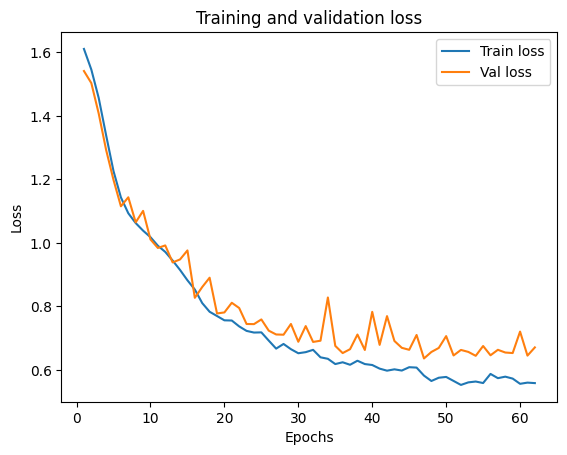

In [108]:
Visualizer.show_training_history(train_losses, val_losses)

In [109]:
model = UnetModel()
checkpoint = torch.load(f"{paths['unet']}/unet_model_epoch_47.pt", weights_only=True, map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

In [110]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, train_data2)

{'accuracy': 0.9960586404800416,
 'dice': 0.4679261064529419,
 'iou': 0.3308244800567627,
 'loss': 0.5600775802135467}

In [111]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, test_data)

{'accuracy': 0.9960835320608956,
 'dice': 0.574522146156856,
 'iou': 0.4180446820599692,
 'loss': 0.4591386318206787}

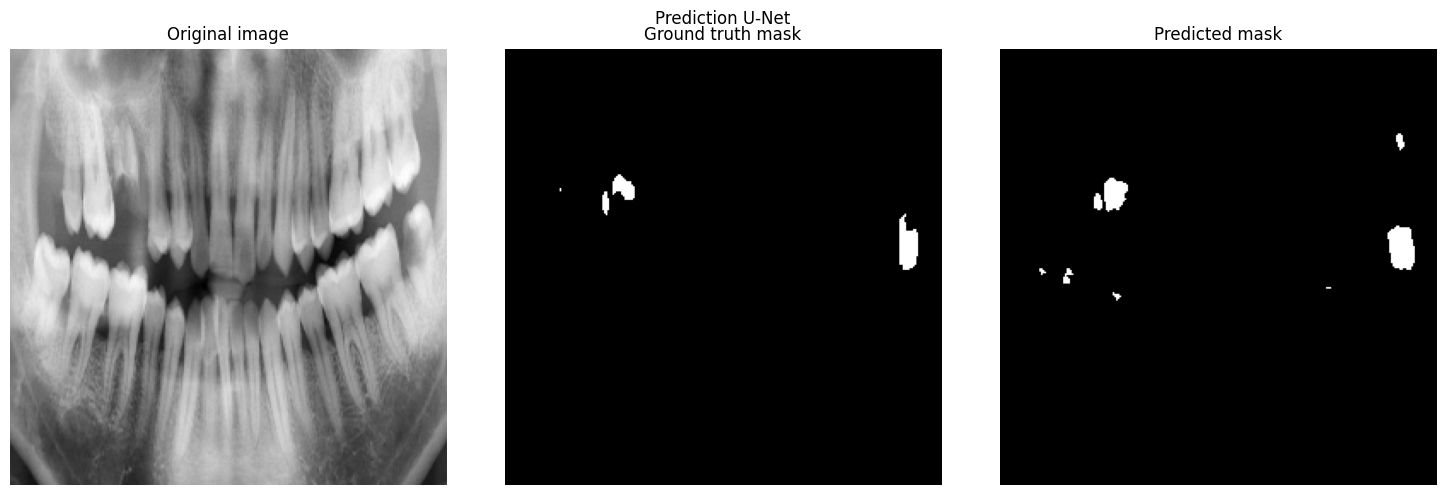

In [112]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample(model, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'U-Net', is_rgb=False)

### Residual U-Net: training, evaluation and inference

In [51]:
model = ResidualUnetModel()
model.to(device)

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

trainer = ModelTrainer(model, optimizer, bce_loss, dice_loss, device)
train_losses, val_losses = trainer.fit(train_data, val_data, 100, f"{paths['res unet']}/residual_unet_model.pt")

Epoch [1/100]: 100%|██████████| 25/25 [00:03<00:00,  7.46it/s, train_loss=1.1144]


val_loss: 1.0192


Epoch [2/100]: 100%|██████████| 25/25 [00:03<00:00,  7.51it/s, train_loss=1.0075]


val_loss: 1.0124


Epoch [3/100]: 100%|██████████| 25/25 [00:03<00:00,  7.50it/s, train_loss=0.9823]


...

val_loss: 0.6649


Epoch [87/100]: 100%|██████████| 25/25 [00:03<00:00,  7.28it/s, train_loss=0.5771]


val_loss: 0.6601


Epoch [88/100]: 100%|██████████| 25/25 [00:03<00:00,  7.11it/s, train_loss=0.5585]


val_loss: 0.6534


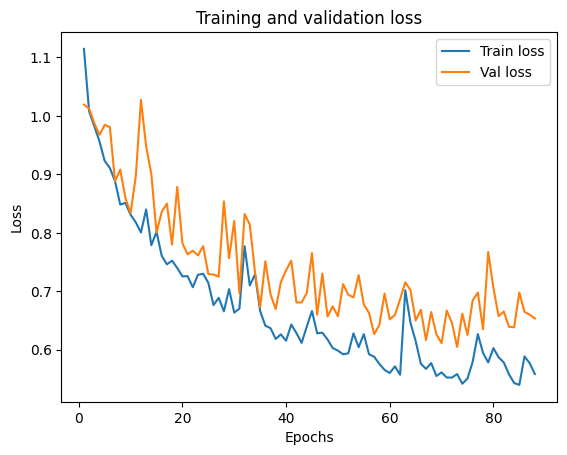

In [52]:
Visualizer.show_training_history(train_losses, val_losses)

In [68]:
model = ResidualUnetModel()
checkpoint = torch.load(f"{paths['res unet']}/residual_unet_model_epoch_73.pt", weights_only=True, map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

In [69]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, train_data2)

{'accuracy': 0.9963170623779297,
 'dice': 0.49864039063453675,
 'iou': 0.36318559408187867,
 'loss': 0.510338122844696}

In [70]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, test_data)

{'accuracy': 0.9961558750697544,
 'dice': 0.5959274768829346,
 'iou': 0.44114609701292856,
 'loss': 0.42896178364753723}

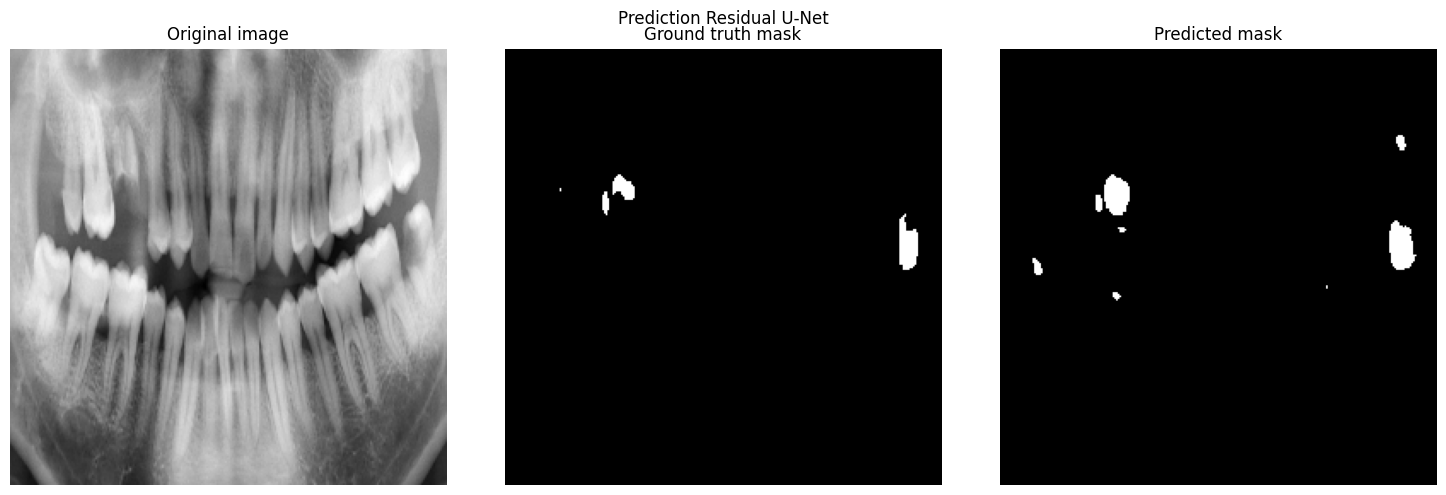

In [71]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample(model, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'Residual U-Net', is_rgb=False)

### Attention U-Net: training, evaluation and inference

In [38]:
model = AttentionUnetModel(is_dropout=True, dropout_rate=0.2)
model.to(device)

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

trainer = ModelTrainer(model, optimizer, bce_loss, dice_loss, device)
train_losses, val_losses = trainer.fit(train_data, val_data, 150, f"{paths['attention unet']}/attention_unet_model.pt")

Epoch [1/150]: 100%|██████████| 25/25 [00:03<00:00,  7.12it/s, train_loss=1.6374]


val_loss: 1.5961


Epoch [2/150]: 100%|██████████| 25/25 [00:03<00:00,  7.27it/s, train_loss=1.5643]


val_loss: 1.5076


Epoch [3/150]: 100%|██████████| 25/25 [00:03<00:00,  7.34it/s, train_loss=1.4616]


...

val_loss: 0.6267


Epoch [89/150]: 100%|██████████| 25/25 [00:03<00:00,  7.30it/s, train_loss=0.5396]


val_loss: 0.6759


Epoch [90/150]: 100%|██████████| 25/25 [00:03<00:00,  7.31it/s, train_loss=0.5445]


val_loss: 0.6322


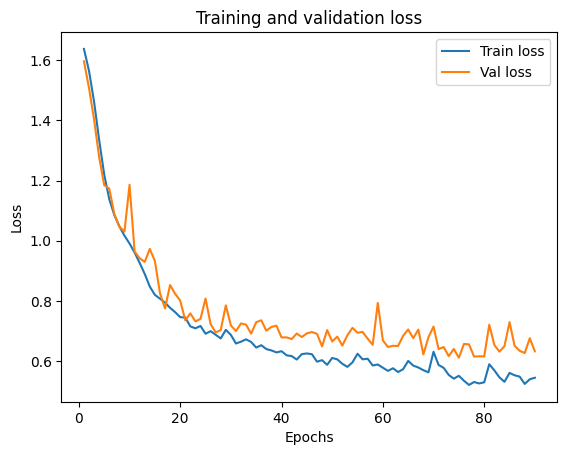

In [39]:
Visualizer.show_training_history(train_losses, val_losses)

In [60]:
model = AttentionUnetModel()
checkpoint = torch.load(f"{paths['attention unet']}/attention_unet_model_epoch_68.pt", weights_only=True, map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

In [61]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, train_data2)

{'accuracy': 0.9963218379020691,
 'dice': 0.5094217419624328,
 'iou': 0.3697082847356796,
 'loss': 0.5022184705734253}

In [62]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, test_data)

{'accuracy': 0.9962218148367745,
 'dice': 0.5960599609783718,
 'iou': 0.4385857198919569,
 'loss': 0.4286021717957088}

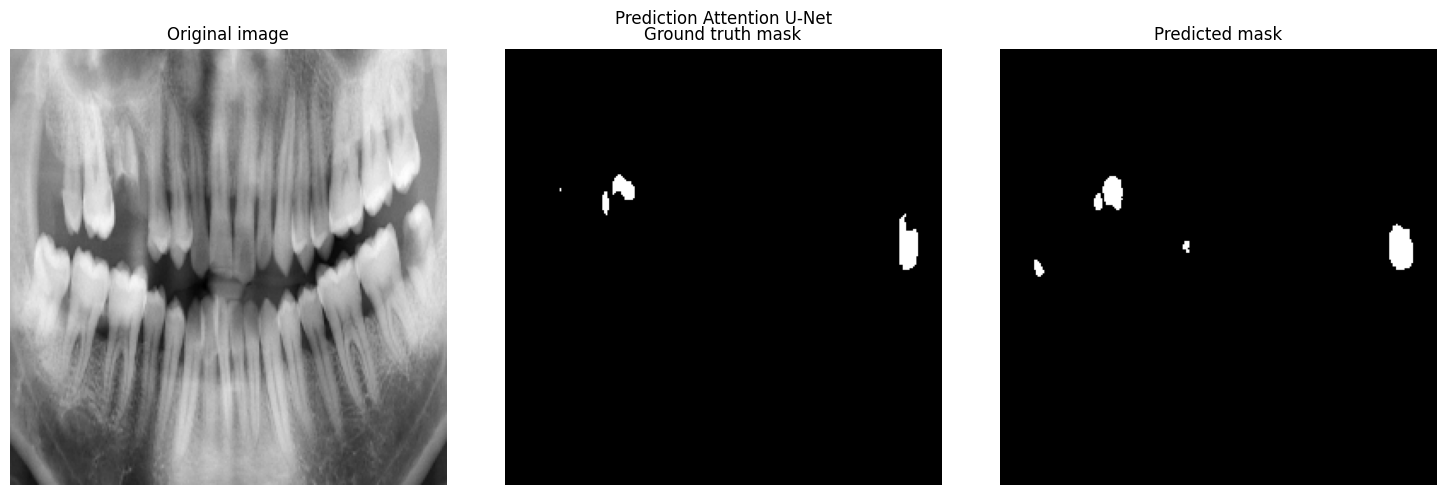

In [63]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample(model, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'Attention U-Net', is_rgb=False)

### Residual attention U-Net: training, evaluation and inference

In [83]:
model = ResidualAttentionUnetModel(is_dropout=True, dropout_rate=0.2)
model.to(device)

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

trainer = ModelTrainer(model, optimizer, bce_loss, dice_loss, device)
train_losses, val_losses = trainer.fit(train_data, val_data, 150, f"{paths['res attention unet']}/residual_attention_unet_model.pt")

Epoch [1/150]: 100%|██████████| 25/25 [00:03<00:00,  6.78it/s, train_loss=1.2525]


val_loss: 1.0231


Epoch [2/150]: 100%|██████████| 25/25 [00:03<00:00,  6.64it/s, train_loss=1.0126]


val_loss: 1.0108


Epoch [3/150]: 100%|██████████| 25/25 [00:03<00:00,  6.71it/s, train_loss=0.9967]


...

val_loss: 0.6874


Epoch [89/150]: 100%|██████████| 25/25 [00:03<00:00,  6.81it/s, train_loss=0.6027]


val_loss: 0.7005


Epoch [90/150]: 100%|██████████| 25/25 [00:03<00:00,  6.82it/s, train_loss=0.6173]


val_loss: 0.7222


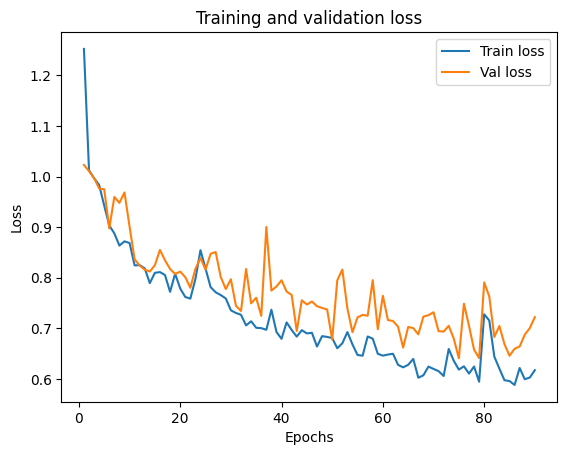

In [84]:
Visualizer.show_training_history(train_losses, val_losses)

In [100]:
model = ResidualAttentionUnetModel()
checkpoint = torch.load(f"{paths['res attention unet']}/residual_attention_unet_model_epoch_75.pt", weights_only=True, map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

In [101]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, train_data2)

{'accuracy': 0.9959698796272278,
 'dice': 0.46973454594612124,
 'iou': 0.3371221512556076,
 'loss': 0.5473579692840577}

In [93]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, test_data)

{'accuracy': 0.9960047858101981,
 'dice': 0.5899093278816768,
 'iou': 0.4350384133202689,
 'loss': 0.43819799593516756}

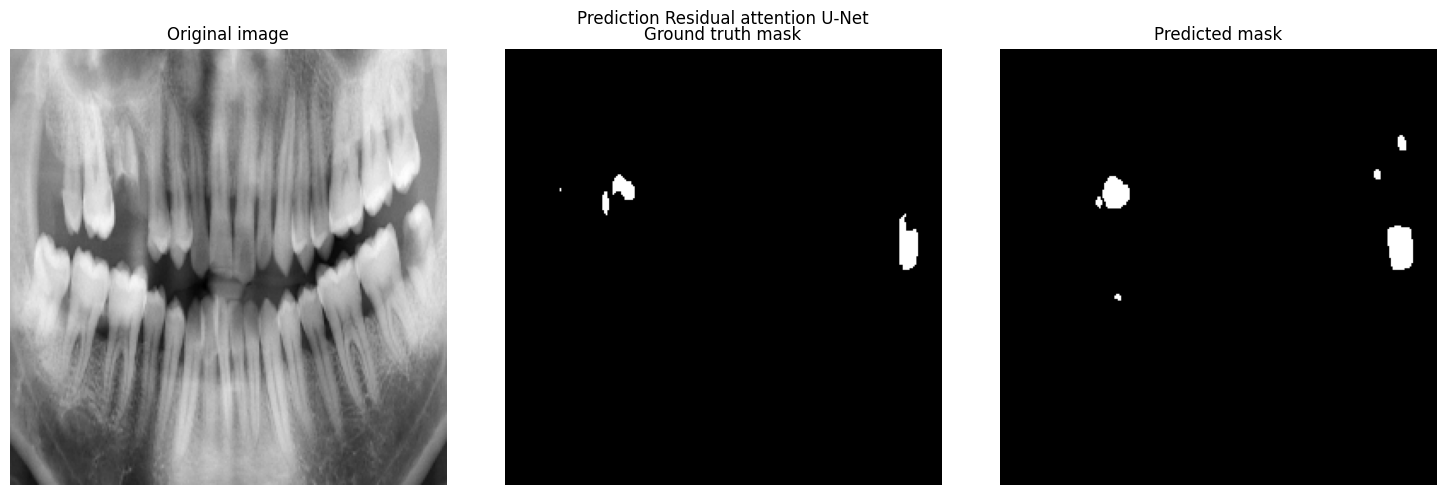

In [94]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample(model, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'Residual attention U-Net', is_rgb=False)

### R2 U-Net: training, evaluation and inference

In [41]:
model = R2UnetModel(is_dropout=True, dropout_rate=0.4)
model.to(device)

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

trainer = ModelTrainer(model, optimizer, bce_loss, dice_loss, device)
train_losses, val_losses = trainer.fit(train_data, val_data, 100, f"{paths['r2 unet']}/r2_unet_model.pt")

Epoch [1/100]: 100%|██████████| 25/25 [00:07<00:00,  3.23it/s, train_loss=1.1195]


val_loss: 1.0207


Epoch [2/100]: 100%|██████████| 25/25 [00:07<00:00,  3.31it/s, train_loss=1.0167]


val_loss: 1.0230


Epoch [3/100]: 100%|██████████| 25/25 [00:07<00:00,  3.32it/s, train_loss=1.0059]


...

val_loss: 0.8343


Epoch [48/100]: 100%|██████████| 25/25 [00:07<00:00,  3.26it/s, train_loss=0.6894]


val_loss: 0.8514


Epoch [49/100]: 100%|██████████| 25/25 [00:07<00:00,  3.20it/s, train_loss=0.6833]


val_loss: 0.8544


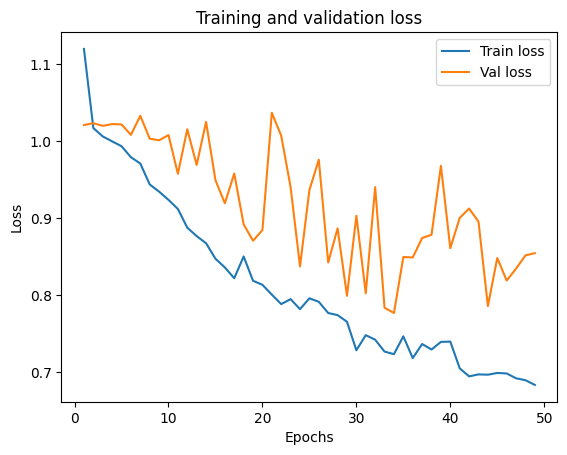

In [42]:
Visualizer.show_training_history(train_losses, val_losses)

In [48]:
model = R2UnetModel()
checkpoint = torch.load(f"{paths['r2 unet']}/r2_unet_model_epoch_33.pt", weights_only=True, map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

In [49]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, train_data2)

{'accuracy': 0.9941215276718139,
 'dice': 0.3212783271074295,
 'iou': 0.21041511595249177,
 'loss': 0.7212716913223267}

In [50]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, test_data)

{'accuracy': 0.9944472994123187,
 'dice': 0.4362301358154842,
 'iou': 0.29517165039266857,
 'loss': 0.6110494477408273}

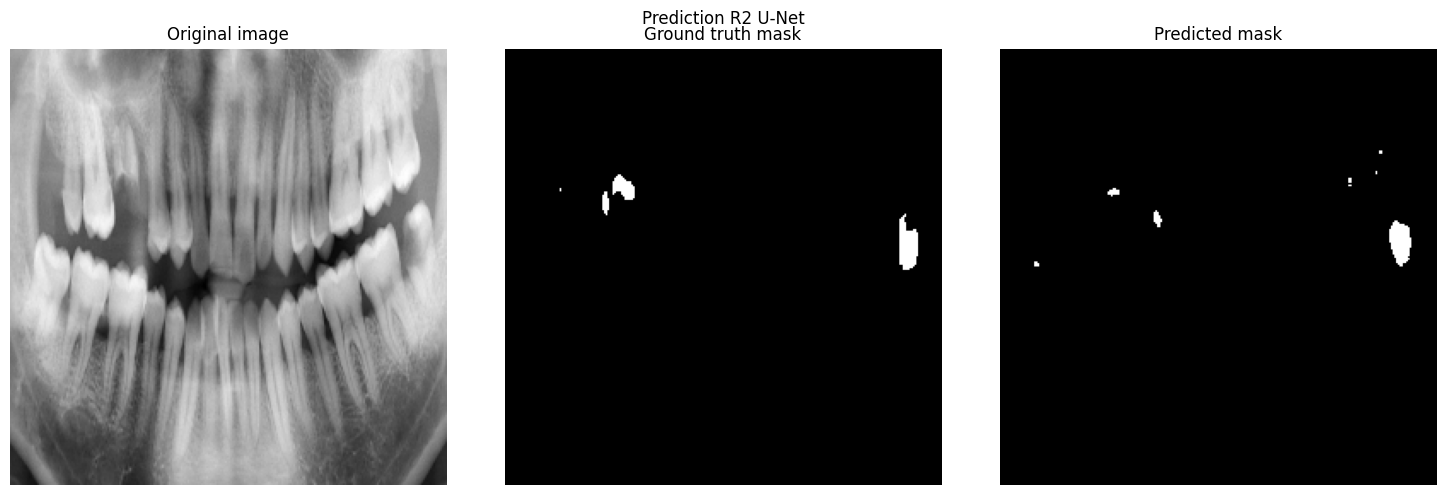

In [51]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample(model, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'R2 U-Net', is_rgb=False)

### U-Net++: training, evaluation and inference

In [38]:
model = UnetPlusPlusModel(deep_supervision=True, is_dropout=True, dropout_rate=0.3)
model.to(device)

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

trainer = ModelTrainer(model, optimizer, bce_loss, dice_loss, device, deep_supervision=True)
train_losses, val_losses = trainer.fit(train_data, val_data, 150, f"{paths['unet++']}/unet_plus_plus_model.pt")

Epoch [1/150]: 100%|██████████| 25/25 [00:07<00:00,  3.15it/s, train_loss=1.6629]


val_loss: 1.5974


Epoch [2/150]: 100%|██████████| 25/25 [00:07<00:00,  3.15it/s, train_loss=1.5876]


val_loss: 1.5431


Epoch [3/150]: 100%|██████████| 25/25 [00:07<00:00,  3.15it/s, train_loss=1.4903]


...

val_loss: 0.6633


Epoch [53/150]: 100%|██████████| 25/25 [00:08<00:00,  3.10it/s, train_loss=0.5989]


val_loss: 0.6607


Epoch [54/150]: 100%|██████████| 25/25 [00:08<00:00,  3.09it/s, train_loss=0.5984]


val_loss: 0.6584


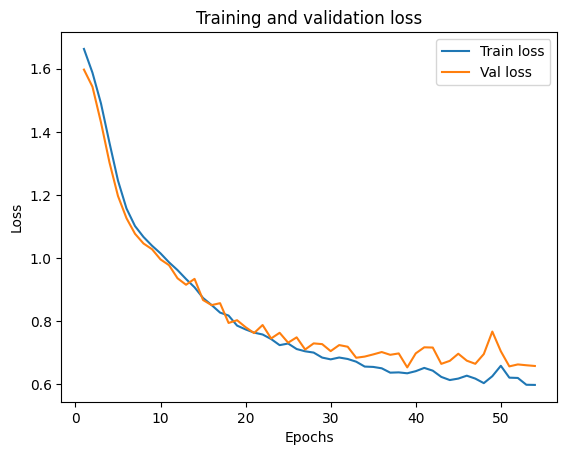

In [39]:
Visualizer.show_training_history(train_losses, val_losses)

In [44]:
model = UnetPlusPlusModel(deep_supervision=True)
checkpoint = torch.load(f"{paths['unet++']}/unet_plus_plus_model_epoch_39.pt", weights_only=True, map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.deep_supervision = False

In [45]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, train_data2)

{'accuracy': 0.9961352849006653,
 'dice': 0.4799083077907562,
 'iou': 0.34416240334510806,
 'loss': 0.5394576036930084}

In [46]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, test_data)

{'accuracy': 0.9959915706089565,
 'dice': 0.5672236595835004,
 'iou': 0.4135737717151642,
 'loss': 0.45973269854273113}

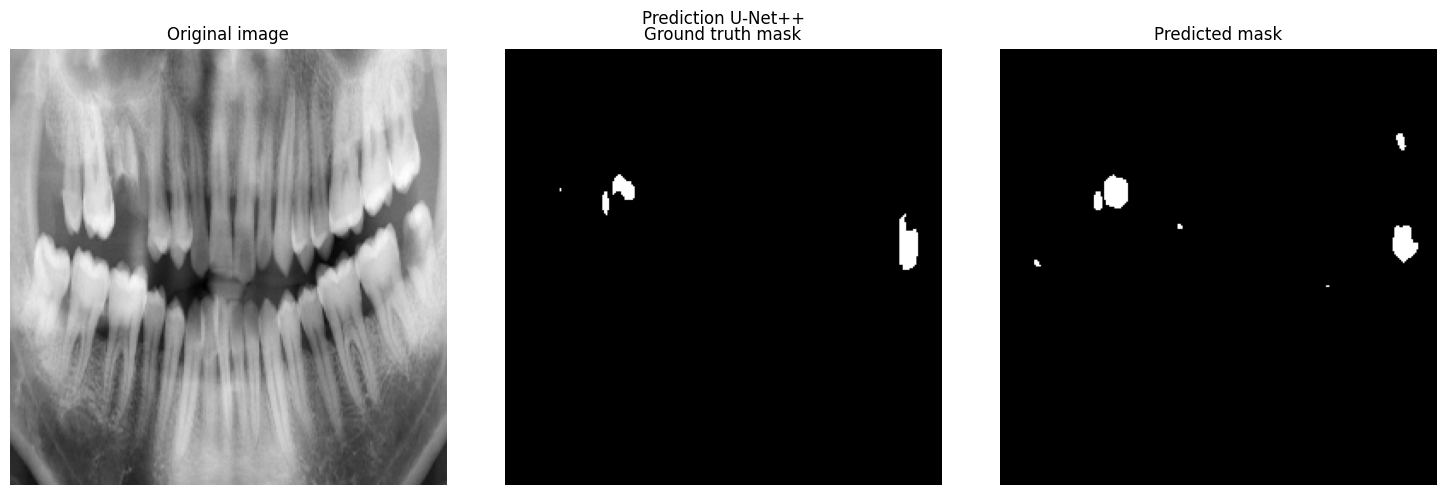

In [47]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample(model, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'U-Net++', is_rgb=False)

### U-Net 3+: training, evaluation and inference

In [31]:
model = Unet3PlusModel(is_dropout=True, dropout_rate=0.3)
model.to(device)

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

trainer = ModelTrainer(model, optimizer, bce_loss, dice_loss, device)
train_losses, val_losses = trainer.fit(train_data, val_data, 150, f"{paths['unet3+']}/unet_3plus_model.pt")

Epoch [1/150]: 100%|██████████| 25/25 [00:17<00:00,  1.45it/s, train_loss=1.6301]


val_loss: 1.6014


Epoch [2/150]: 100%|██████████| 25/25 [00:15<00:00,  1.59it/s, train_loss=1.5581]


val_loss: 1.5004


Epoch [3/150]: 100%|██████████| 25/25 [00:15<00:00,  1.58it/s, train_loss=1.4570]


...

val_loss: 0.6118


Epoch [112/150]: 100%|██████████| 25/25 [00:15<00:00,  1.59it/s, train_loss=0.4850]


val_loss: 0.6383


Epoch [113/150]: 100%|██████████| 25/25 [00:15<00:00,  1.59it/s, train_loss=0.4869]


val_loss: 0.6024


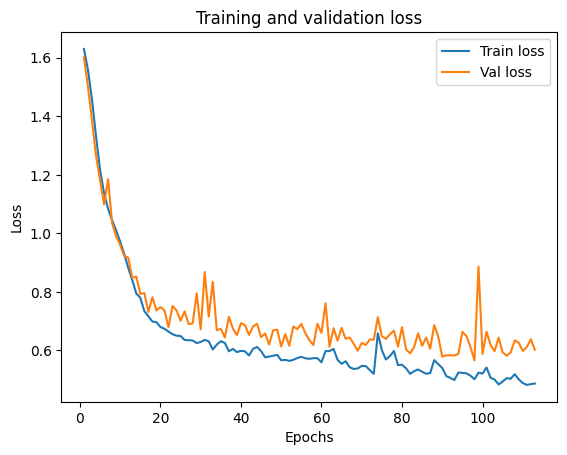

In [32]:
Visualizer.show_training_history(train_losses, val_losses)

In [40]:
model = Unet3PlusModel()
checkpoint = torch.load(f"{paths['unet3+']}/unet_3plus_model_epoch_98.pt", weights_only=True, map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

In [41]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, train_data2)

{'accuracy': 0.9967318105697632,
 'dice': 0.5412854433059693,
 'iou': 0.4013728356361389,
 'loss': 0.4665662944316864}

In [42]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, test_data)

{'accuracy': 0.9964347566877093,
 'dice': 0.6134810447692871,
 'iou': 0.4584231546946934,
 'loss': 0.4124430332865034}

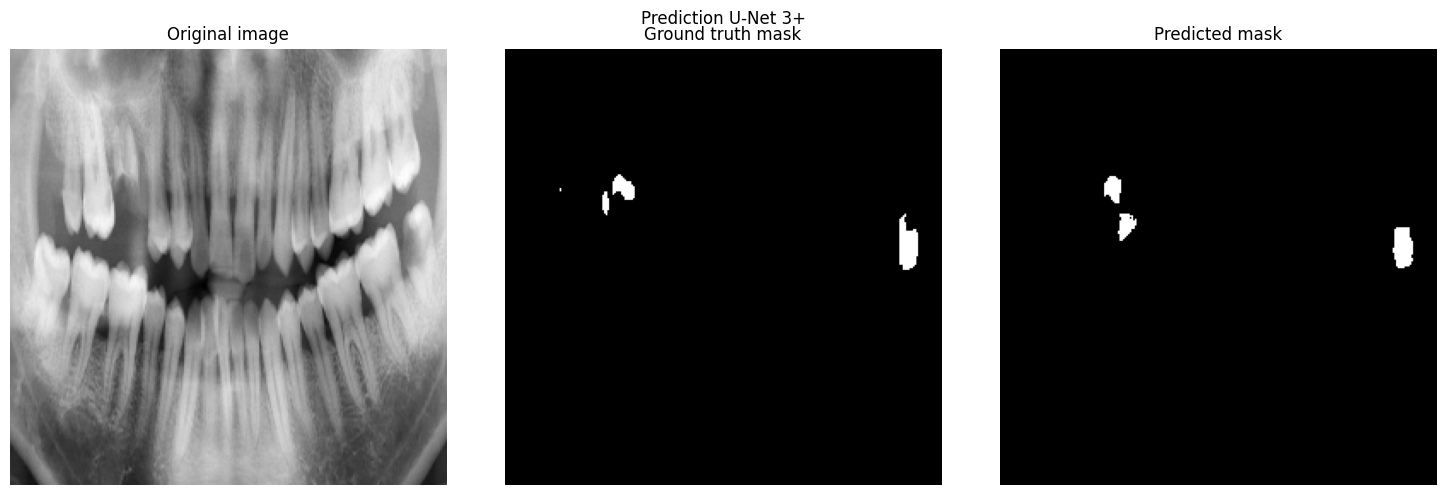

In [43]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample(model, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'U-Net 3+', is_rgb=False)

### SE U-Net: training, evaluation and inference

In [47]:
model = SeUnetModel()
model.to(device)

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

trainer = ModelTrainer(model, optimizer, bce_loss, dice_loss, device)
train_losses, val_losses = trainer.fit(train_data, val_data, 150, f"{paths['se unet']}/se_unet_model.pt")

Epoch [1/150]: 100%|██████████| 25/25 [00:03<00:00,  7.11it/s, train_loss=1.5914]


val_loss: 1.4894


Epoch [2/150]: 100%|██████████| 25/25 [00:03<00:00,  7.65it/s, train_loss=1.3164]


val_loss: 1.2739


Epoch [3/150]: 100%|██████████| 25/25 [00:03<00:00,  7.74it/s, train_loss=1.1526]


...

val_loss: 0.6460


Epoch [138/150]: 100%|██████████| 25/25 [00:03<00:00,  7.71it/s, train_loss=0.5340]


val_loss: 0.6422


Epoch [139/150]: 100%|██████████| 25/25 [00:03<00:00,  7.68it/s, train_loss=0.5226]


val_loss: 0.6624


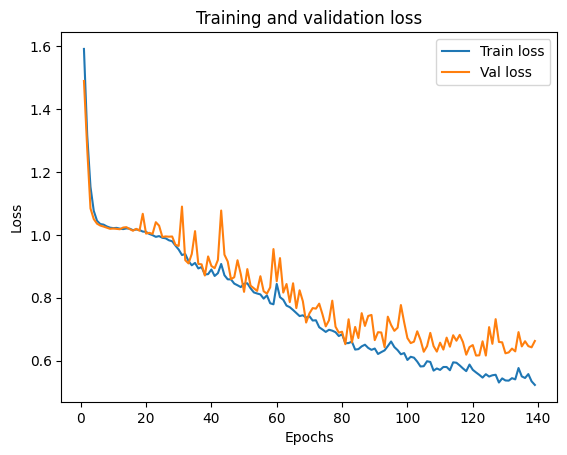

In [48]:
Visualizer.show_training_history(train_losses, val_losses)

In [56]:
model = SeUnetModel()
checkpoint = torch.load(f"{paths['se unet']}/se_unet_model_epoch_124.pt", weights_only=True, map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

In [57]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, train_data2)

{'accuracy': 0.996648108959198,
 'dice': 0.5016858232021332,
 'iou': 0.36752342820167544,
 'loss': 0.5103679144382477}

In [58]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, test_data)

{'accuracy': 0.9965102331978934,
 'dice': 0.5952636514391217,
 'iou': 0.44257465856415884,
 'loss': 0.4280103700501578}

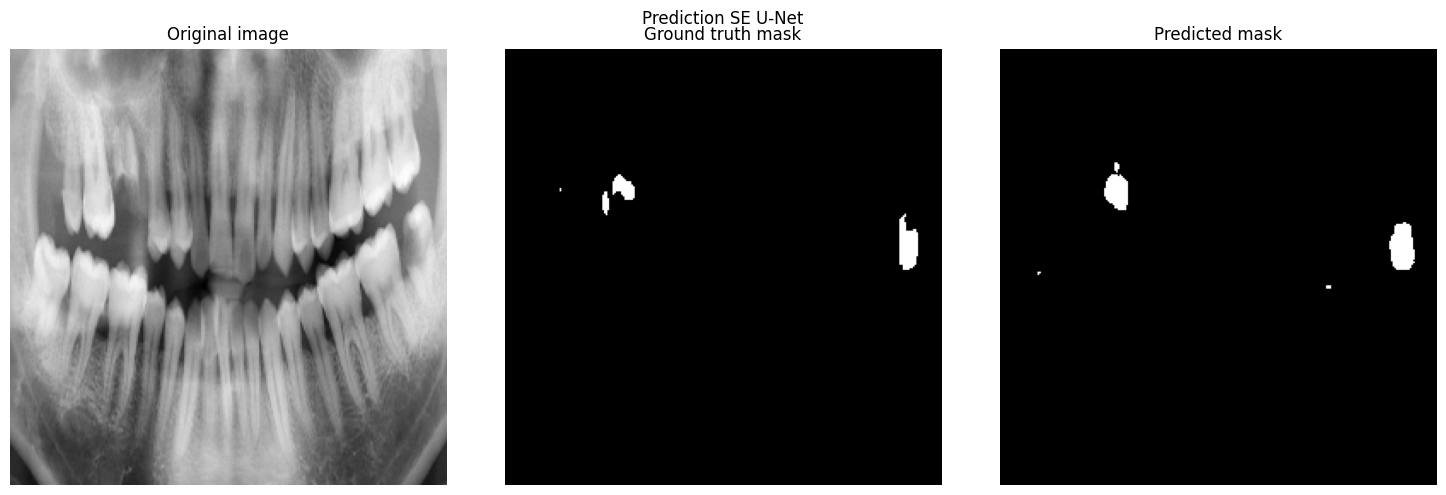

In [59]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample(model, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'SE U-Net', is_rgb=False)

### Dense U-Net: training, evaluation and inference

In [33]:
model = DenseUnetModel(num_layers_per_block=4)
model.to(device)

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

trainer = ModelTrainer(model, optimizer, bce_loss, dice_loss, device)
train_losses, val_losses = trainer.fit(train_data, val_data, 150, f"{paths['dense unet']}/dense_unet_model.pt")

Epoch [1/150]: 100%|██████████| 50/50 [00:14<00:00,  3.45it/s, train_loss=1.0705]


val_loss: 1.2186


Epoch [2/150]: 100%|██████████| 50/50 [00:14<00:00,  3.45it/s, train_loss=1.0085]


val_loss: 1.1946


Epoch [3/150]: 100%|██████████| 50/50 [00:14<00:00,  3.44it/s, train_loss=0.9834]


...

val_loss: 0.6527


Epoch [61/150]: 100%|██████████| 50/50 [00:14<00:00,  3.43it/s, train_loss=0.5716]


val_loss: 0.7016


Epoch [62/150]: 100%|██████████| 50/50 [00:14<00:00,  3.43it/s, train_loss=0.5743]


val_loss: 0.6319


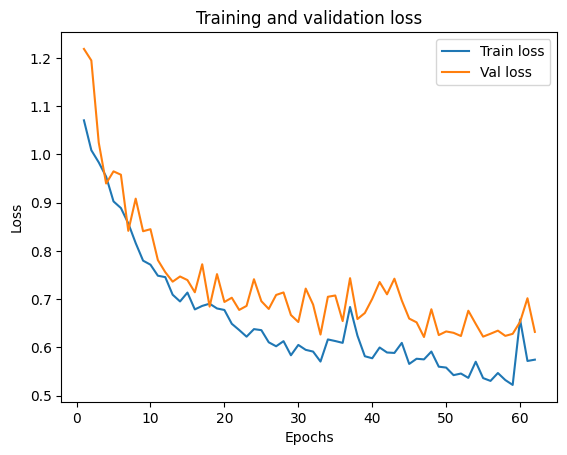

In [34]:
Visualizer.show_training_history(train_losses, val_losses)

In [35]:
model = DenseUnetModel()
checkpoint = torch.load(f"{paths['dense unet']}/dense_unet_model_epoch_47.pt", weights_only=True, map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

In [36]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, train_data2)

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


{'accuracy': 0.9961224365234375,
 'dice': 0.4914150995016098,
 'iou': 0.35478218644857407,
 'loss': 0.5210974264144898}

In [37]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, test_data)

{'accuracy': 0.9962444305419922,
 'dice': 0.6002470759245065,
 'iou': 0.44362138784848726,
 'loss': 0.42784496454092175}

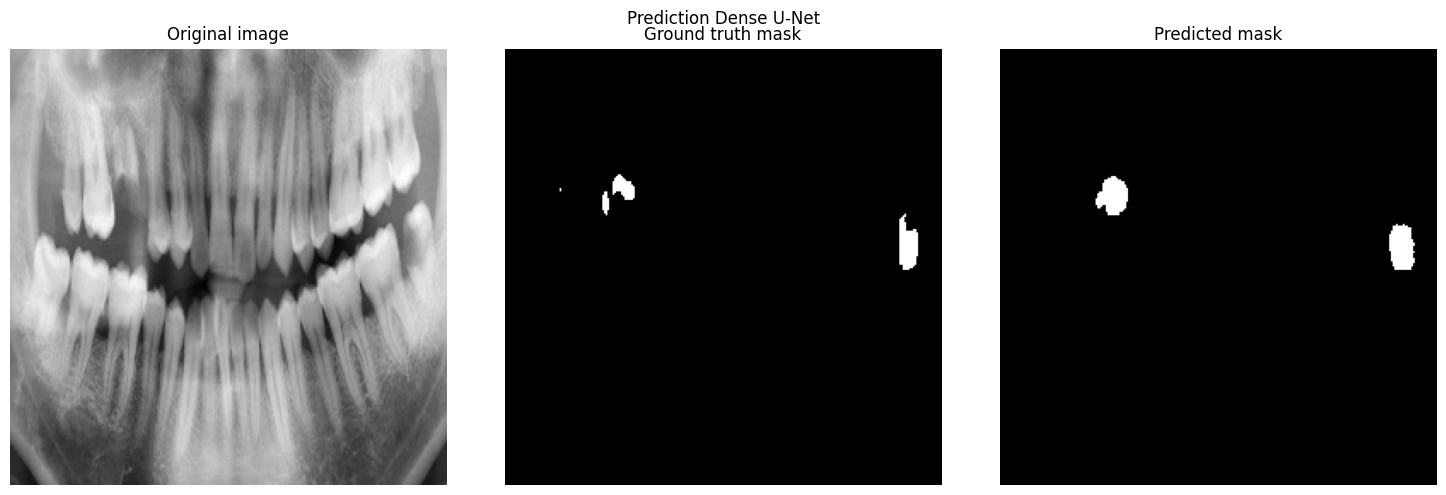

In [38]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample(model, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'Dense U-Net', is_rgb=False)

### DeepLabV3+: training, evaluation and inference

In [33]:
model = DeepLabV3PlusModel()
model.to(device)

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

trainer = ModelTrainer(model, optimizer, bce_loss, dice_loss, device)
train_losses, val_losses = trainer.fit(train_data, val_data, 100, f"{paths['deeplabv3+']}/deeplabv3plus_model.pt")

Epoch [1/100]: 100%|██████████| 25/25 [00:02<00:00, 10.81it/s, train_loss=2.0089]


val_loss: 1.7710


Epoch [2/100]: 100%|██████████| 25/25 [00:02<00:00, 11.22it/s, train_loss=1.0334]


val_loss: 1.8099


Epoch [3/100]: 100%|██████████| 25/25 [00:02<00:00, 11.06it/s, train_loss=0.9958]


...

val_loss: 0.6551


Epoch [63/100]: 100%|██████████| 25/25 [00:02<00:00, 11.00it/s, train_loss=0.6060]


val_loss: 0.6920


Epoch [64/100]: 100%|██████████| 25/25 [00:02<00:00, 11.54it/s, train_loss=0.6018]


val_loss: 0.6502


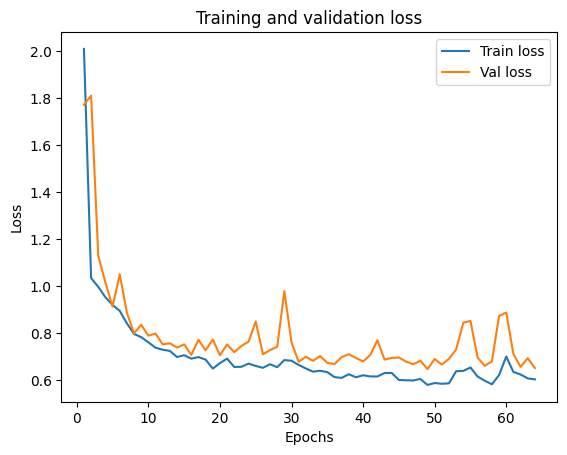

In [34]:
Visualizer.show_training_history(train_losses, val_losses)

In [35]:
model = DeepLabV3PlusModel()
checkpoint = torch.load(f"{paths['deeplabv3+']}/deeplabv3plus_model_epoch_49.pt", weights_only=True, map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

In [36]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, train_data2)

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


{'accuracy': 0.9963087320327759,
 'dice': 0.4797885477542877,
 'iou': 0.34456789374351504,
 'loss': 0.5299702203273773}

In [37]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_model(model, test_data)

{'accuracy': 0.9960806710379464,
 'dice': 0.555625353540693,
 'iou': 0.39974009139197214,
 'loss': 0.4736082937036242}

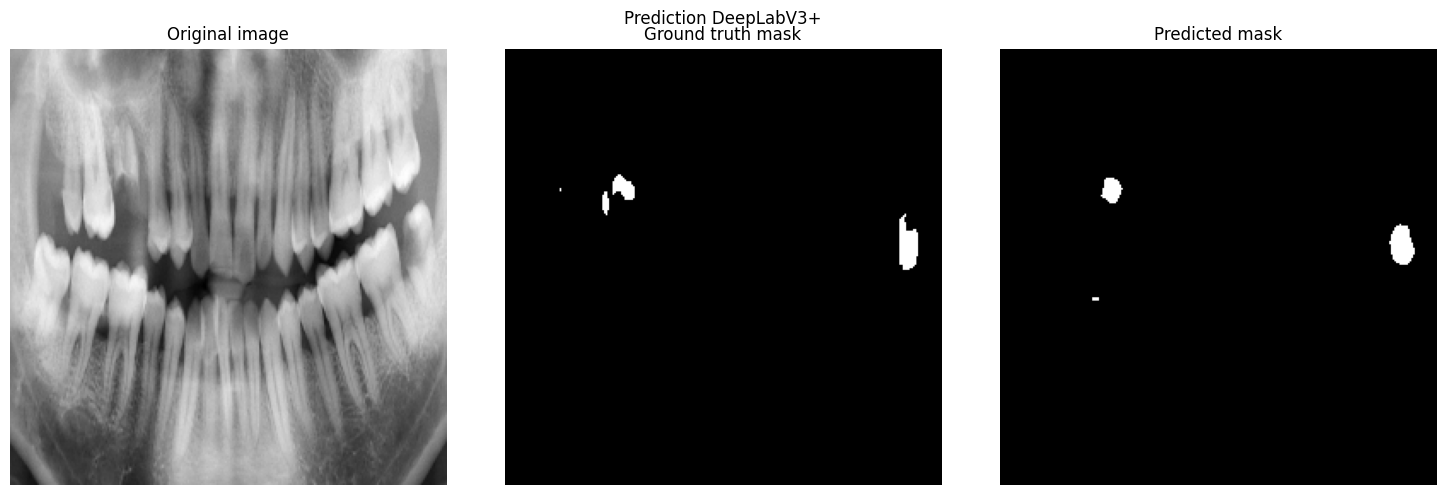

In [38]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample(model, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'DeepLabV3+', is_rgb=False)

### Multiple models: evaluation and inference

In [39]:
model1 = AttentionUnetModel()
checkpoint1 = torch.load(f"{paths['attention unet']}/attention_unet_model_epoch_68.pt", weights_only=True, map_location=torch.device(device))
model1.load_state_dict(checkpoint1['model_state_dict'])
model1 = model1.to(device)

model2 = Unet3PlusModel()
checkpoint2 = torch.load(f"{paths['unet3+']}/unet_3plus_model_epoch_98.pt", weights_only=True, map_location=torch.device(device))
model2.load_state_dict(checkpoint2['model_state_dict'])
model2 = model2.to(device)

model3 = DenseUnetModel()
checkpoint3 = torch.load(f"{paths['dense unet']}/dense_unet_model_epoch_47.pt", weights_only=True, map_location=torch.device(device))
model3.load_state_dict(checkpoint3['model_state_dict'])
model3 = model3.to(device)

models = [model1, model2, model3]

In [40]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_models(models, train_data2)

{'accuracy': 0.9968135595321655,
 'dice': 0.5447346639633178,
 'iou': 0.4049587118625641}

In [41]:
model_eval = ModelEvaluator(bce_loss, dice_loss, device)
model_eval.evaluate_models(models, test_data)

{'accuracy': 0.9966982432774135,
 'dice': 0.63151615858078,
 'iou': 0.47531175187655855}

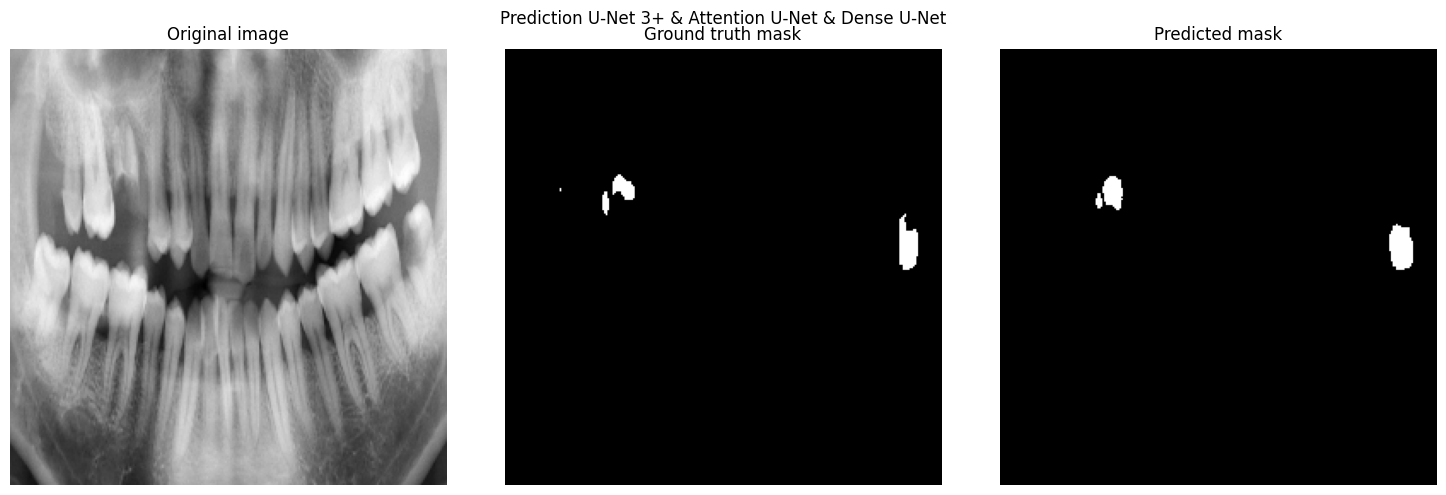

In [42]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)

predicted_mask = ModelPredictor.predict_sample_for_models(models, image, device)
Visualizer.show_prediction(image.squeeze(0).cpu(), mask.cpu(), predicted_mask.cpu(), 'U-Net 3+ & Attention U-Net & Dense U-Net', is_rgb=False)

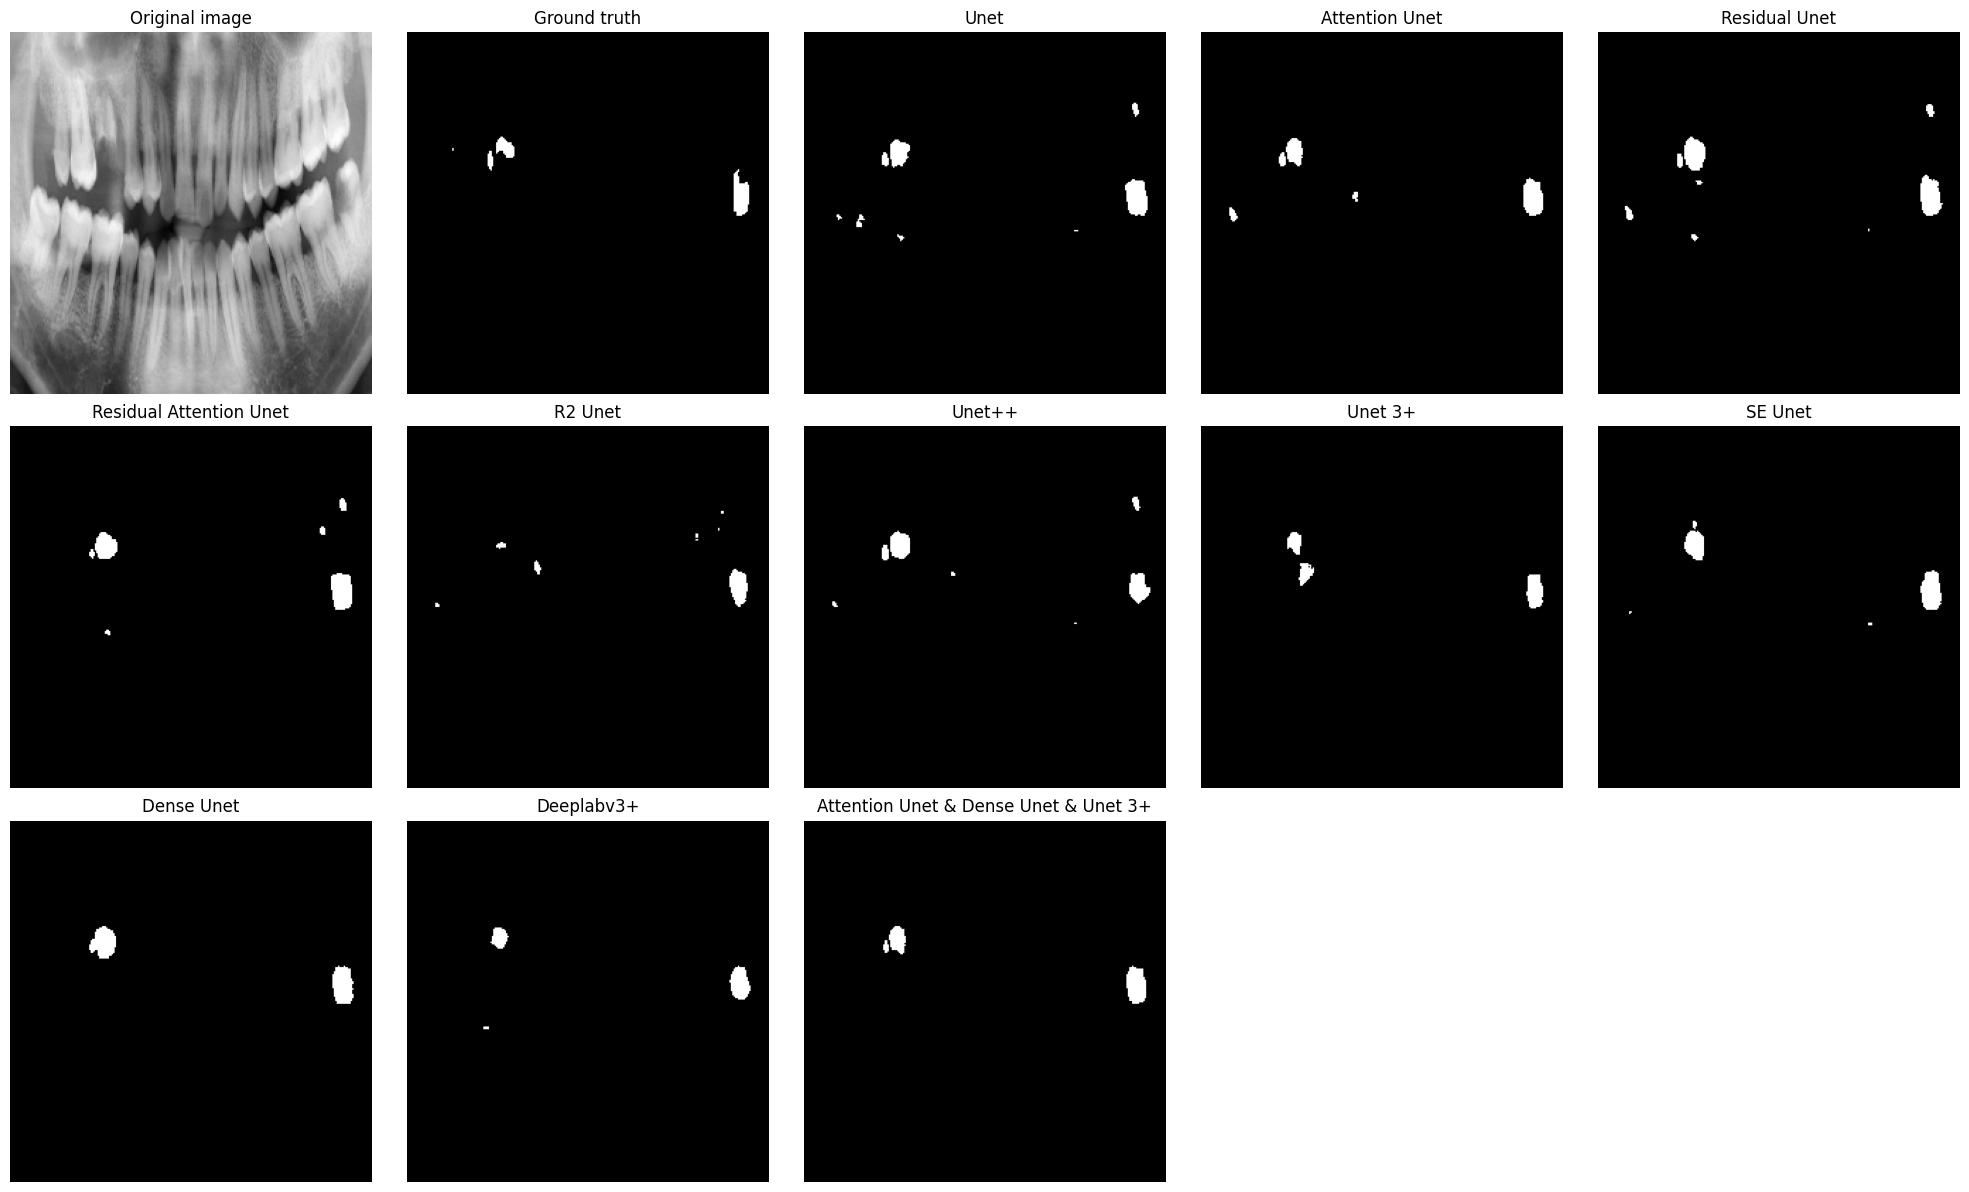

In [32]:
image, mask = load_image_and_mask(test_img_path, test_mask_path, transform, is_rgb=False)
predicted_masks = []
titles = ['Unet', 'Attention Unet', 'Residual Unet', 'Residual Attention Unet', 
          'R2 Unet', 'Unet++', 'Unet 3+', 'SE Unet', 'Dense Unet', 
          'Deeplabv3+', 'Attention Unet & Dense Unet & Unet 3+']

model1 = UnetModel()
checkpoint1 = torch.load(f"{paths['unet']}/unet_model_epoch_47.pt", weights_only=True, map_location=torch.device(device))
model1.load_state_dict(checkpoint1['model_state_dict'])
model1 = model1.to(device)
predicted_masks.append(ModelPredictor.predict_sample(model1, image, device))


model2 = AttentionUnetModel()
checkpoint2 = torch.load(f"{paths['attention unet']}/attention_unet_model_epoch_68.pt", weights_only=True, map_location=torch.device(device))
model2.load_state_dict(checkpoint2['model_state_dict'])
model2 = model2.to(device)
predicted_masks.append(ModelPredictor.predict_sample(model2, image, device))


model3 = ResidualUnetModel()
checkpoint3 = torch.load(f"{paths['res unet']}/residual_unet_model_epoch_73.pt", weights_only=True, map_location=torch.device(device))
model3.load_state_dict(checkpoint3['model_state_dict'])
model3 = model3.to(device)
predicted_masks.append(ModelPredictor.predict_sample(model3, image, device))


model4 = ResidualAttentionUnetModel()
checkpoint4 = torch.load(f"{paths['res attention unet']}/residual_attention_unet_model_epoch_75.pt", weights_only=True, map_location=torch.device(device))
model4.load_state_dict(checkpoint4['model_state_dict'])
model4 = model4.to(device)
predicted_masks.append(ModelPredictor.predict_sample(model4, image, device))


model5 = R2UnetModel()
checkpoint5 = torch.load(f"{paths['r2 unet']}/r2_unet_model_epoch_33.pt", weights_only=True, map_location=torch.device(device))
model5.load_state_dict(checkpoint5['model_state_dict'])
model5 = model5.to(device)
predicted_masks.append(ModelPredictor.predict_sample(model5, image, device))


model6 = UnetPlusPlusModel(deep_supervision=True)
checkpoint6 = torch.load(f"{paths['unet++']}/unet_plus_plus_model_epoch_39.pt", weights_only=True, map_location=torch.device(device))
model6.load_state_dict(checkpoint6['model_state_dict'])
model6 = model6.to(device)
model6.deep_supervision = False
predicted_masks.append(ModelPredictor.predict_sample(model6, image, device))


model7 = Unet3PlusModel()
checkpoint7 = torch.load(f"{paths['unet3+']}/unet_3plus_model_epoch_98.pt", weights_only=True, map_location=torch.device(device))
model7.load_state_dict(checkpoint7['model_state_dict'])
model7 = model7.to(device)
predicted_masks.append(ModelPredictor.predict_sample(model7, image, device))


model8 = SeUnetModel()
checkpoint8 = torch.load(f"{paths['se unet']}/se_unet_model_epoch_124.pt", weights_only=True, map_location=torch.device(device))
model8.load_state_dict(checkpoint8['model_state_dict'])
model8 = model8.to(device)
predicted_masks.append(ModelPredictor.predict_sample(model8, image, device))


model9 = DenseUnetModel()
checkpoint9 = torch.load(f"{paths['dense unet']}/dense_unet_model_epoch_47.pt", weights_only=True, map_location=torch.device(device))
model9.load_state_dict(checkpoint9['model_state_dict'])
model9 = model9.to(device)
predicted_masks.append(ModelPredictor.predict_sample(model9, image, device))


model10 = DeepLabV3PlusModel()
checkpoint10 = torch.load(f"{paths['deeplabv3+']}/deeplabv3plus_model_epoch_49.pt", weights_only=True, map_location=torch.device(device))
model10.load_state_dict(checkpoint10['model_state_dict'])
model10 = model10.to(device)
predicted_masks.append(ModelPredictor.predict_sample(model10, image, device))


predicted_masks.append(ModelPredictor.predict_sample_for_models([model2, model9, model7], image, device))

predicted_masks = [mask.cpu() for mask in predicted_masks]

Visualizer.show_predictions(image.squeeze(0).cpu(), mask.cpu(), predicted_masks, titles, ncols=5)